Total failed puzzles: 313
Total test images: 5999
Failure rate: 5.22%
Success rate: 94.78%

=== FAILURE ANALYSIS ===
Average piece accuracy in failed cases: 0.839
Median piece accuracy in failed cases: 0.875
Worst case accuracy: 0.125
Best failed case accuracy: 0.875


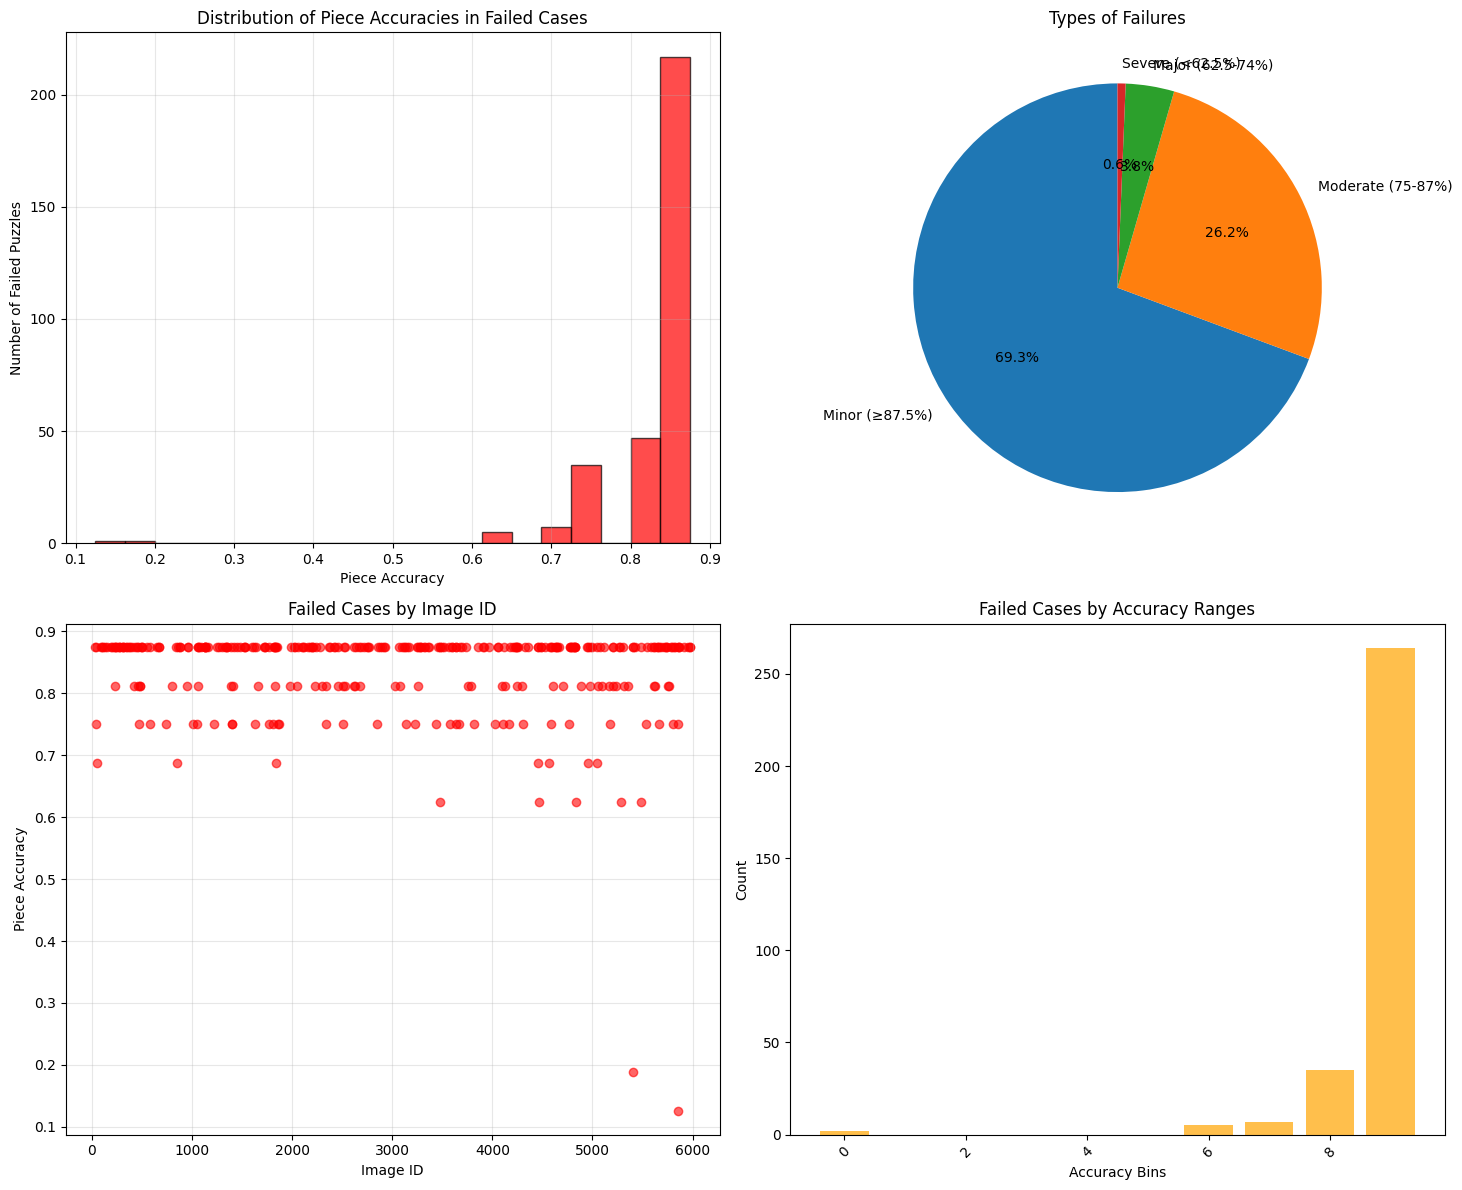


=== FAILURE BREAKDOWN ===
Minor (≥87.5%): 217 cases (69.3%)
Moderate (75-87%): 82 cases (26.2%)
Major (62.5-74%): 12 cases (3.8%)
Severe (<62.5%): 2 cases (0.6%)

=== WORST CASES (for manual inspection) ===
Image 5851: 0.125 accuracy (14 pieces wrong)
Image 5406: 0.188 accuracy (12 pieces wrong)
Image 3477: 0.625 accuracy (6 pieces wrong)
Image 4464: 0.625 accuracy (6 pieces wrong)
Image 4834: 0.625 accuracy (6 pieces wrong)
Image 5289: 0.625 accuracy (6 pieces wrong)
Image 5483: 0.625 accuracy (6 pieces wrong)
Image   52: 0.688 accuracy (4 pieces wrong)
Image  849: 0.688 accuracy (4 pieces wrong)
Image 1843: 0.688 accuracy (4 pieces wrong)

=== FAILURE DISTRIBUTION ANALYSIS ===
Images    0-1000:  54 failures
Images 1000-2000:  55 failures
Images 2000-3000:  46 failures
Images 3000-4000:  45 failures
Images 4000-5000:  57 failures
Images 5000-6000:  56 failures


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Load the failed puzzles data
failed_data = pd.read_csv('failed_puzzles.log', 
                         names=['image_id', 'piece_accuracy', 'perfect_puzzle'])

print(f"Total failed puzzles: {len(failed_data)}")
print(f"Total test images: 5999")
print(f"Failure rate: {len(failed_data)/5999*100:.2f}%")
print(f"Success rate: {(5999-len(failed_data))/5999*100:.2f}%")

# Basic statistics
print("\n=== FAILURE ANALYSIS ===")
print(f"Average piece accuracy in failed cases: {failed_data['piece_accuracy'].mean():.3f}")
print(f"Median piece accuracy in failed cases: {failed_data['piece_accuracy'].median():.3f}")
print(f"Worst case accuracy: {failed_data['piece_accuracy'].min():.3f}")
print(f"Best failed case accuracy: {failed_data['piece_accuracy'].max():.3f}")

# Categorize failures
def categorize_failure(acc):
    if acc >= 0.875:
        return "Minor (≥87.5%)"  # 1-2 pieces wrong
    elif acc >= 0.75:
        return "Moderate (75-87%)"  # 2-4 pieces wrong  
    elif acc >= 0.625:
        return "Major (62.5-74%)"  # 4-6 pieces wrong
    else:
        return "Severe (<62.5%)"  # 6+ pieces wrong

failed_data['failure_type'] = failed_data['piece_accuracy'].apply(categorize_failure)

# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of piece accuracies in failed cases
ax1.hist(failed_data['piece_accuracy'], bins=20, alpha=0.7, color='red', edgecolor='black')
ax1.set_xlabel('Piece Accuracy')
ax1.set_ylabel('Number of Failed Puzzles')
ax1.set_title('Distribution of Piece Accuracies in Failed Cases')
ax1.grid(True, alpha=0.3)

# 2. Failure categories pie chart
failure_counts = failed_data['failure_type'].value_counts()
ax2.pie(failure_counts.values, labels=failure_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Types of Failures')

# 3. Piece accuracy over image IDs (to see if failures cluster)
ax3.scatter(failed_data['image_id'], failed_data['piece_accuracy'], alpha=0.6, color='red')
ax3.set_xlabel('Image ID')
ax3.set_ylabel('Piece Accuracy')
ax3.set_title('Failed Cases by Image ID')
ax3.grid(True, alpha=0.3)

# 4. Count of failures by accuracy bins
accuracy_bins = pd.cut(failed_data['piece_accuracy'], bins=10)
bin_counts = accuracy_bins.value_counts().sort_index()
ax4.bar(range(len(bin_counts)), bin_counts.values, alpha=0.7, color='orange')
ax4.set_xlabel('Accuracy Bins')
ax4.set_ylabel('Count')
ax4.set_title('Failed Cases by Accuracy Ranges')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print detailed breakdown
print("\n=== FAILURE BREAKDOWN ===")
for category, count in failure_counts.items():
    print(f"{category}: {count} cases ({count/len(failed_data)*100:.1f}%)")

# Find worst cases for manual inspection
print("\n=== WORST CASES (for manual inspection) ===")
worst_cases = failed_data.nsmallest(10, 'piece_accuracy')
for _, row in worst_cases.iterrows():
    pieces_wrong = int(16 * (1 - row['piece_accuracy']))
    print(f"Image {row['image_id']:4d}: {row['piece_accuracy']:.3f} accuracy ({pieces_wrong} pieces wrong)")

# Check if failures are clustered in certain image ID ranges
print("\n=== FAILURE DISTRIBUTION ANALYSIS ===")
id_ranges = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 6000)]
for start, end in id_ranges:
    range_failures = failed_data[(failed_data['image_id'] >= start) & (failed_data['image_id'] < end)]
    print(f"Images {start:4d}-{end:4d}: {len(range_failures):3d} failures")

=== CHECKING SAVED IMAGES ===
Total files in results: 65989
Final images found: 5999
Example filenames:
  3104_final.png
  238_final.png
  4442_final.png
  1521_final.png
  3216_final.png
  1604_final.png
  5119_final.png
  1817_final.png
  4385_final.png
  4765_final.png

=== VISUALIZING WORST CASES ===


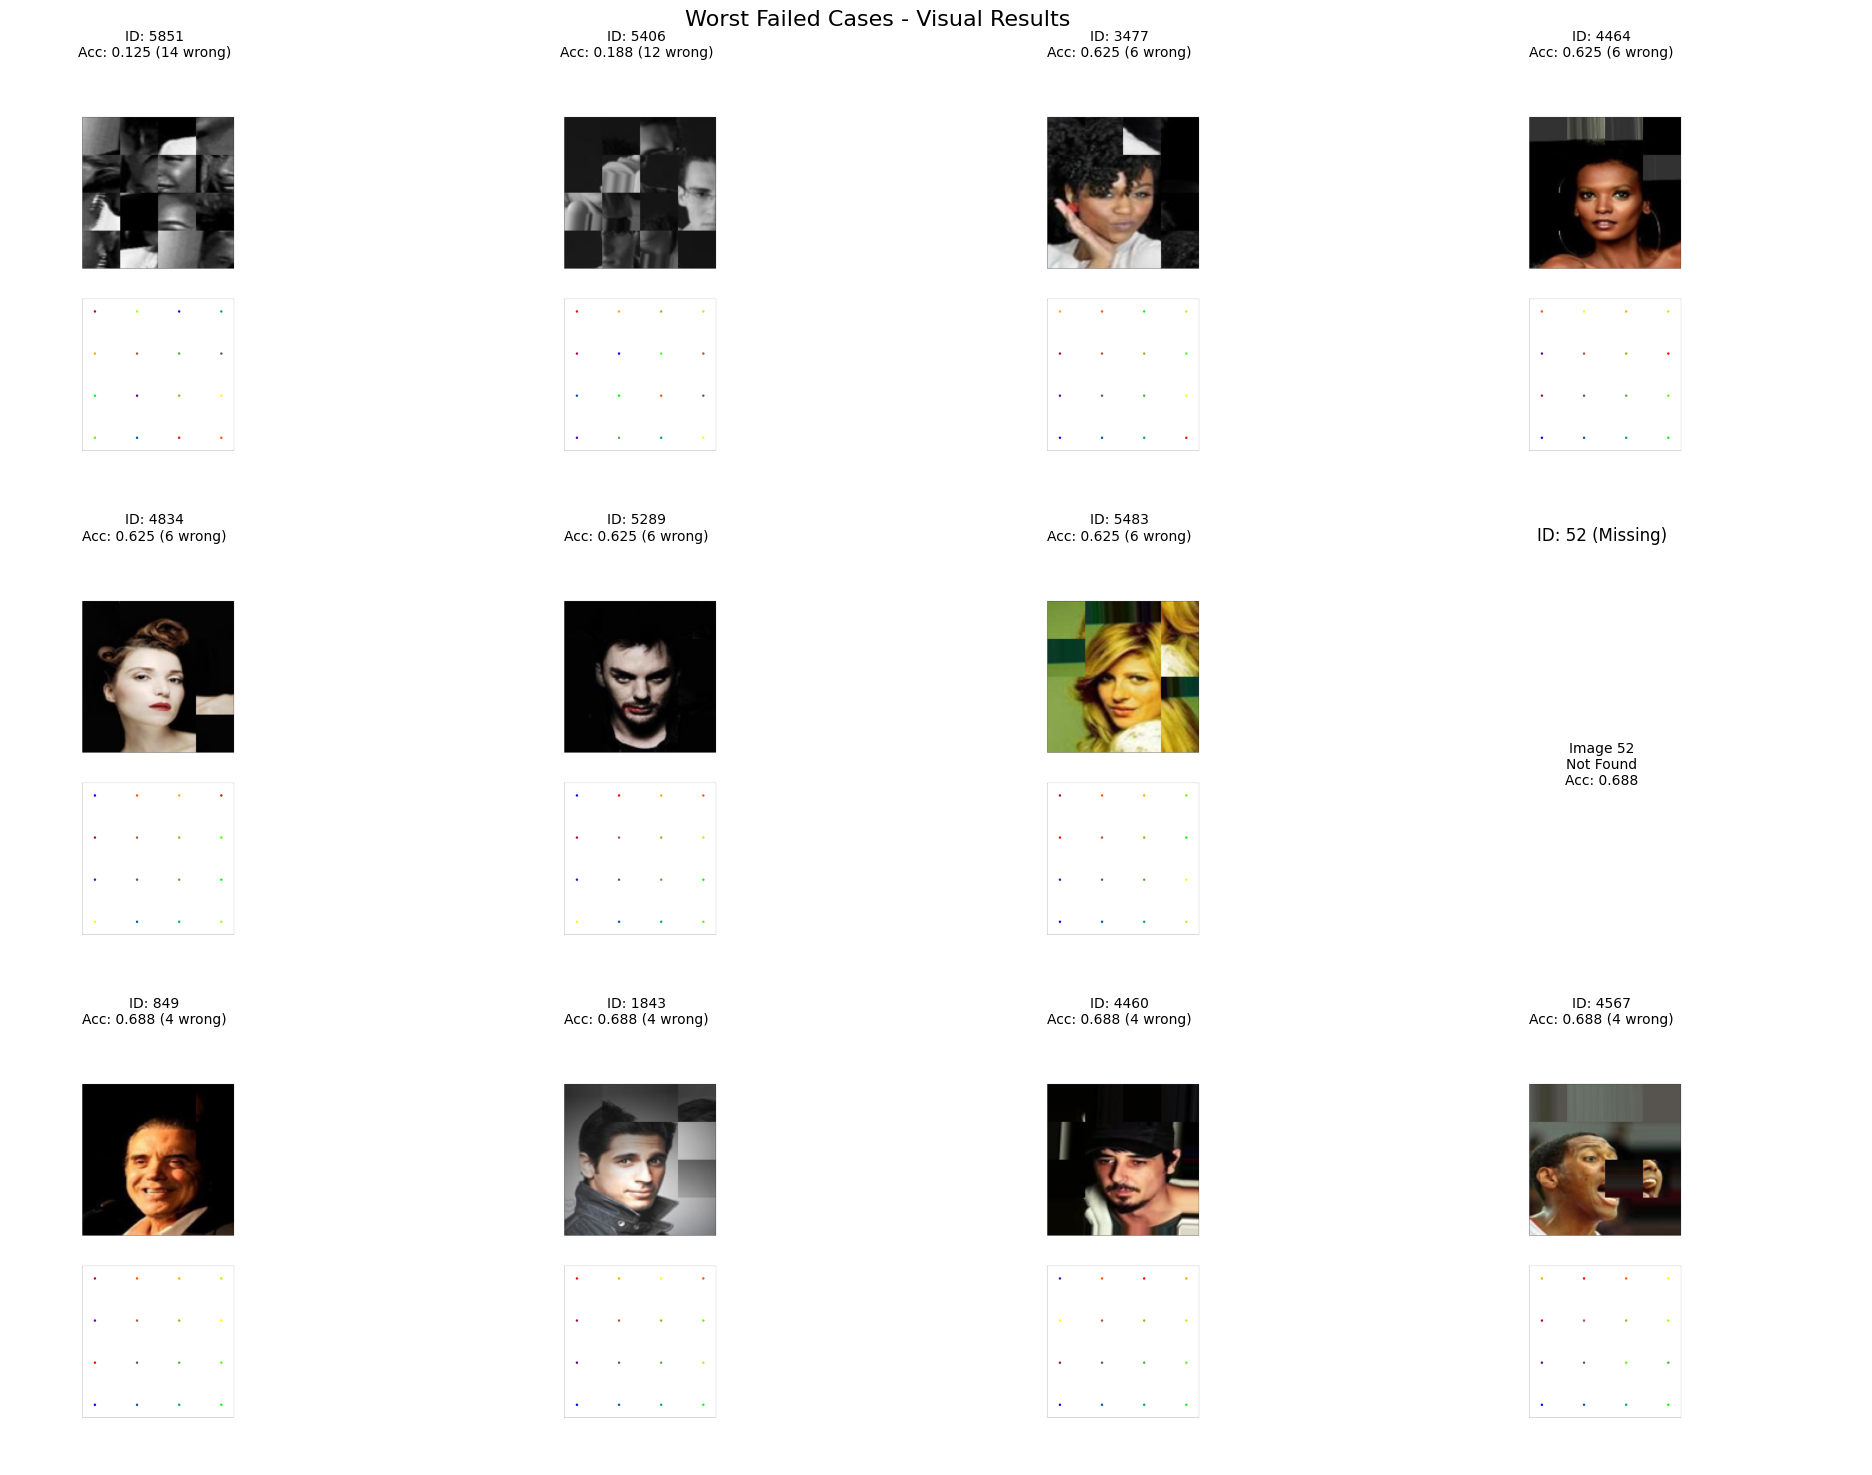

In [3]:
# Add this new cell to visualize the actual failed puzzle images
import matplotlib.pyplot as plt
from PIL import Image
import os

# Path to your saved results
results_path = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/celeba-[(4, 4)]-300-degree:100%-virtnode:4-nkobid-continuous-ours_dropout-arch-transformer/test/"

def visualize_failed_cases(num_cases=12, case_type="worst"):
    """
    Visualize failed puzzle cases
    case_type: "worst", "random", "severe", "moderate"
    """
    
    if case_type == "worst":
        cases_to_show = failed_data.nsmallest(num_cases, 'piece_accuracy')
    elif case_type == "random":
        cases_to_show = failed_data.sample(num_cases)
    elif case_type == "severe":
        severe_cases = failed_data[failed_data['failure_type'].str.contains('Severe|Major')]
        cases_to_show = severe_cases.head(num_cases)
    elif case_type == "moderate":
        moderate_cases = failed_data[failed_data['failure_type'].str.contains('Moderate')]
        cases_to_show = moderate_cases.head(num_cases)
    
    # Create subplot grid
    cols = 4
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
    axes = axes.flatten() if num_cases > 1 else [axes]
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc))
        
        # Try to find the final image file
        possible_names = [
            f"{image_id:03d}_000_final.png",
            f"{image_id:04d}_000_final.png", 
            f"{image_id:05d}_000_final.png",
            f"{image_id:03d}_final.png",
            f"{image_id:04d}_final.png",
            f"{image_id:05d}_final.png"
        ]
        
        image_found = False
        for name in possible_names:
            image_path = os.path.join(results_path, name)
            if os.path.exists(image_path):
                try:
                    img = Image.open(image_path)
                    axes[idx].imshow(img)
                    axes[idx].set_title(f'ID: {image_id}\nAcc: {piece_acc:.3f} ({pieces_wrong} wrong)', 
                                      fontsize=10)
                    axes[idx].axis('off')
                    image_found = True
                    break
                except Exception as e:
                    continue
        
        if not image_found:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f'ID: {image_id} (Missing)')
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{case_type.title()} Failed Cases - Visual Results', fontsize=16)
    plt.tight_layout()
    plt.show()

# Check what files exist in the results directory
print("=== CHECKING SAVED IMAGES ===")
if os.path.exists(results_path):
    files = os.listdir(results_path)
    print(f"Total files in results: {len(files)}")
    
    # Show some example filenames to understand the naming pattern
    final_images = [f for f in files if 'final' in f.lower()]
    print(f"Final images found: {len(final_images)}")
    print("Example filenames:")
    for i, fname in enumerate(final_images[:10]):
        print(f"  {fname}")
    
    # Now visualize the worst cases
    print("\n=== VISUALIZING WORST CASES ===")
    visualize_failed_cases(num_cases=12, case_type="worst")
    
else:
    print(f"Results path not found: {results_path}")
    print("Please check the path or run evaluation with --save_eval_images True first")


=== VISUALIZING WORST CASES (2 per row) ===


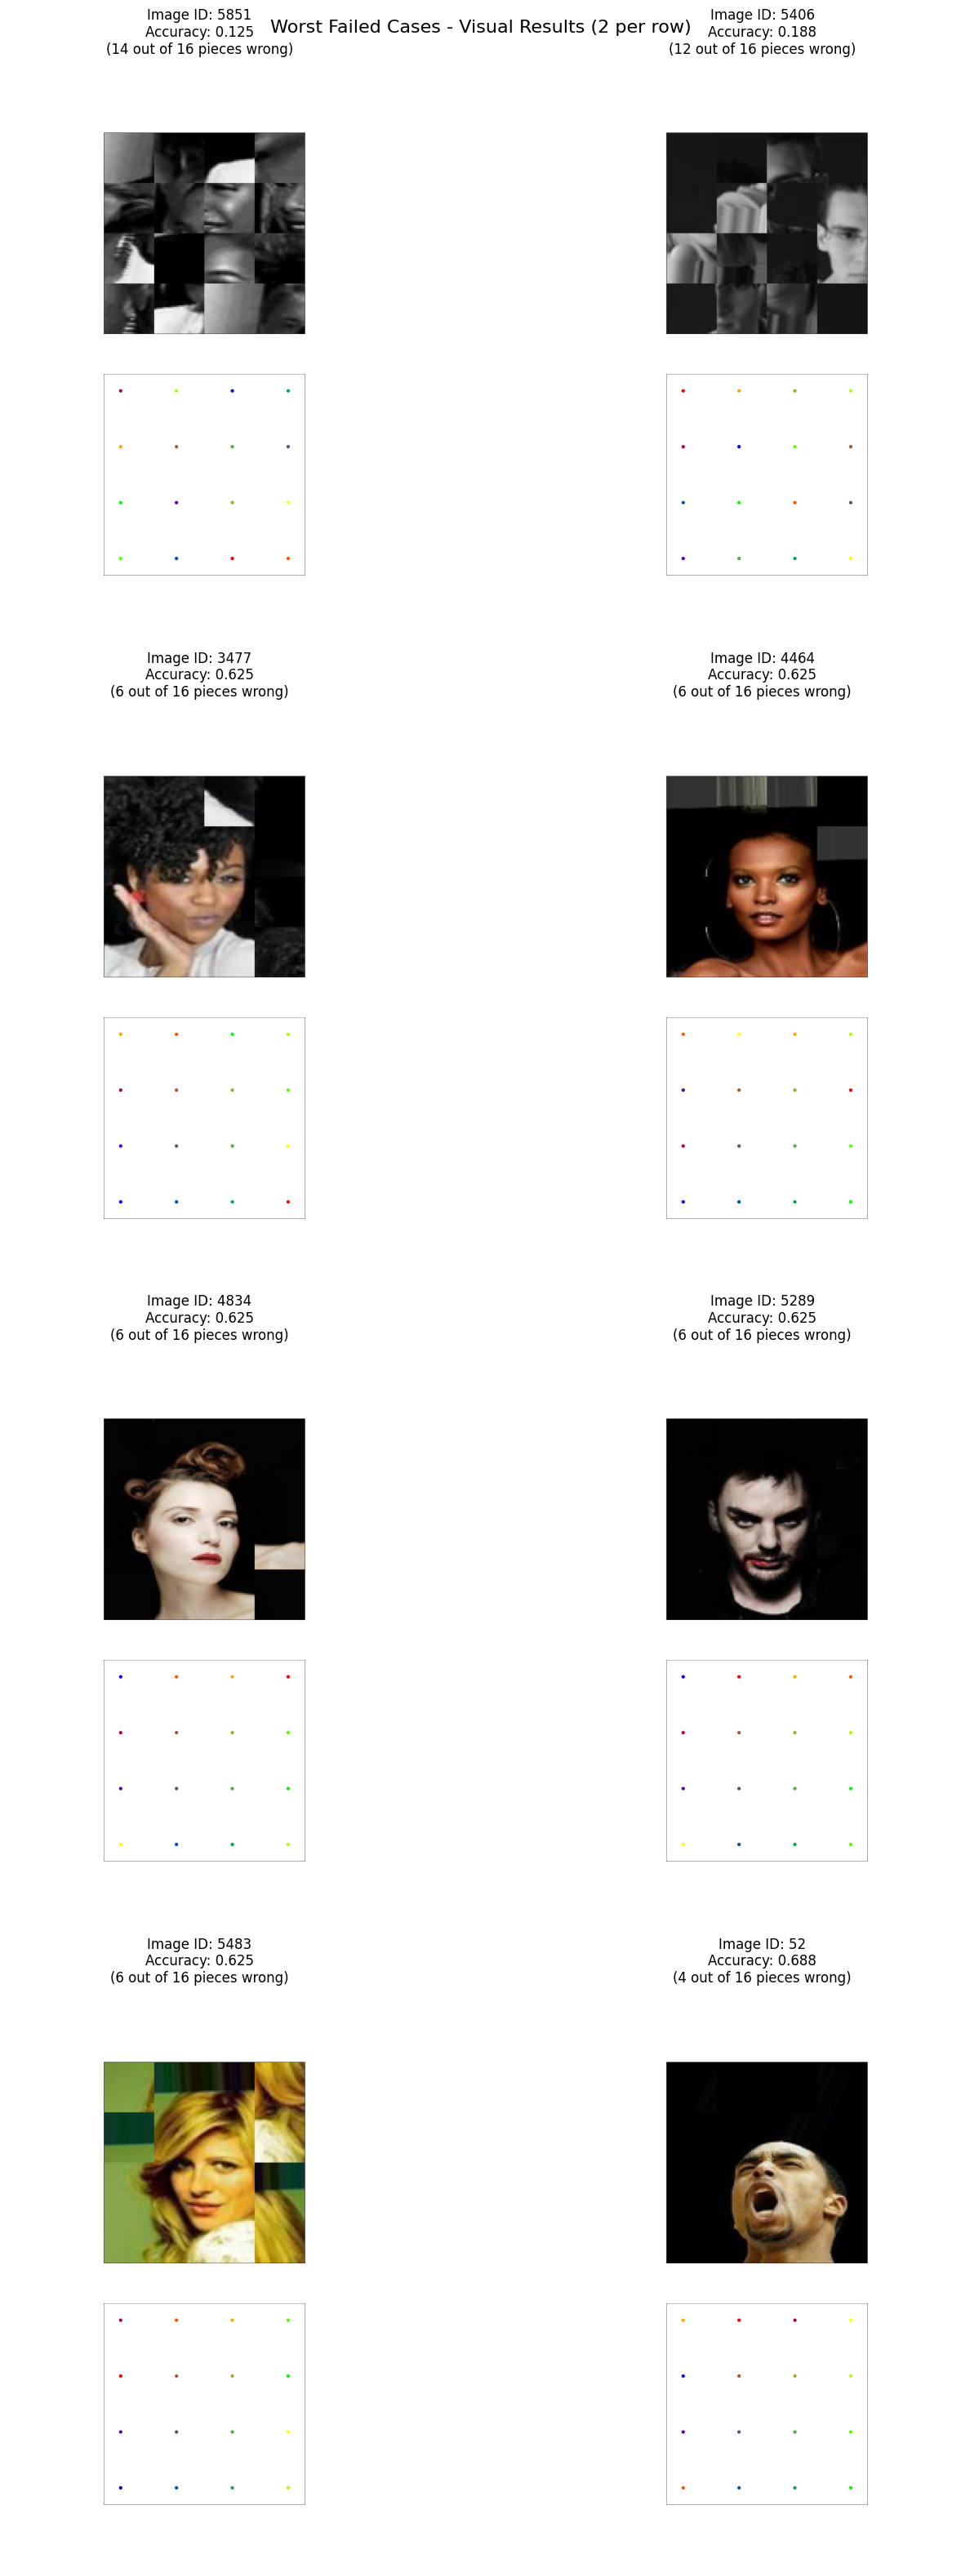


=== VISUALIZING MODERATE FAILURES (2 per row) ===


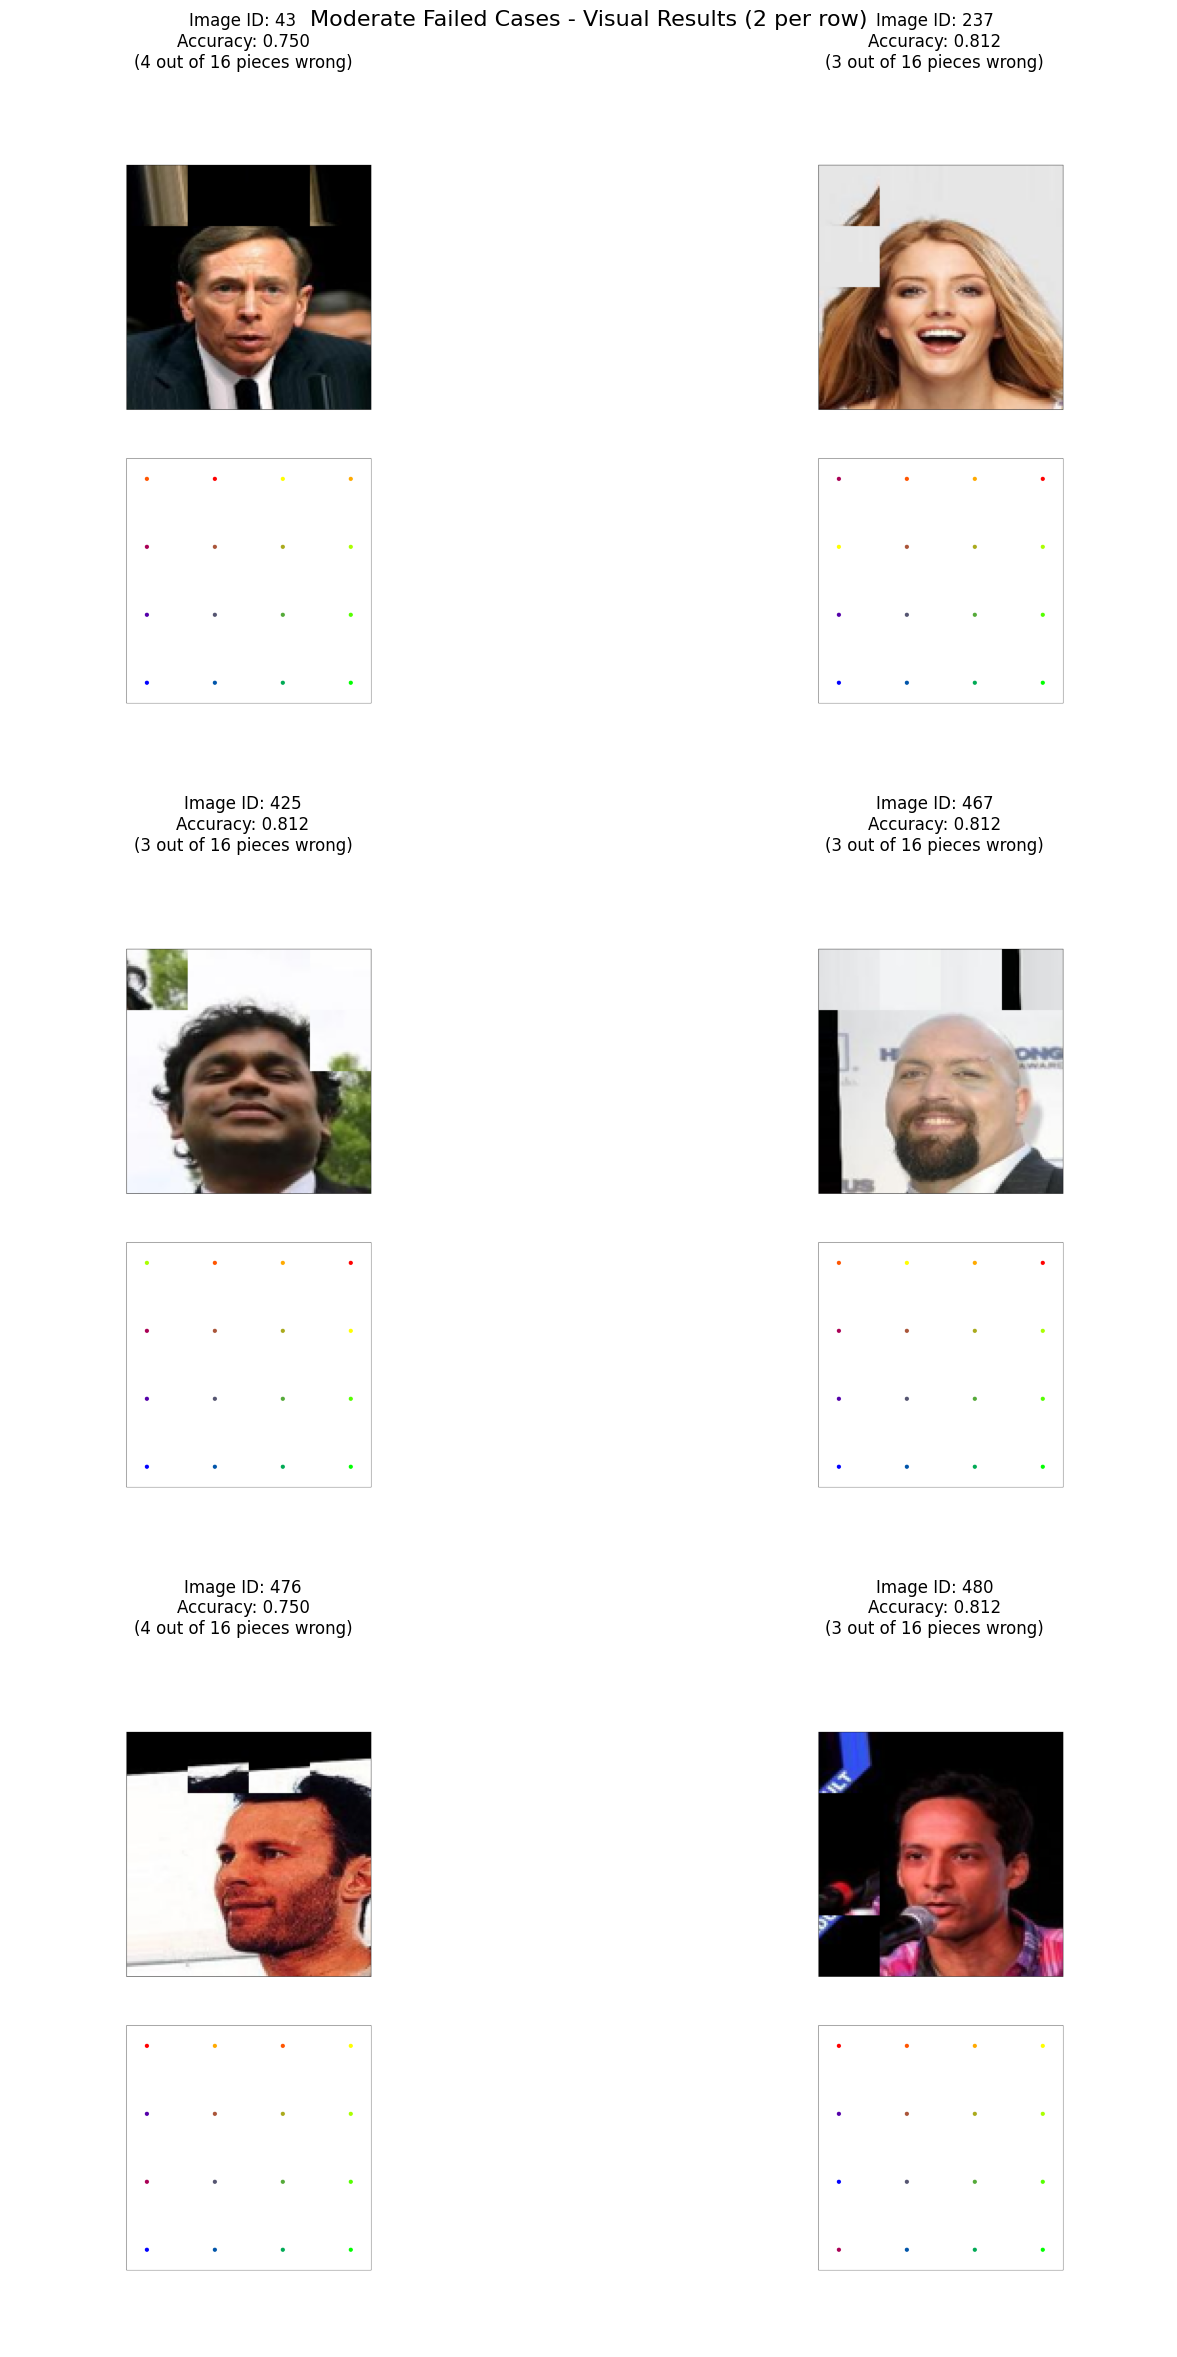


=== VISUALIZING RANDOM SAMPLE (2 per row) ===


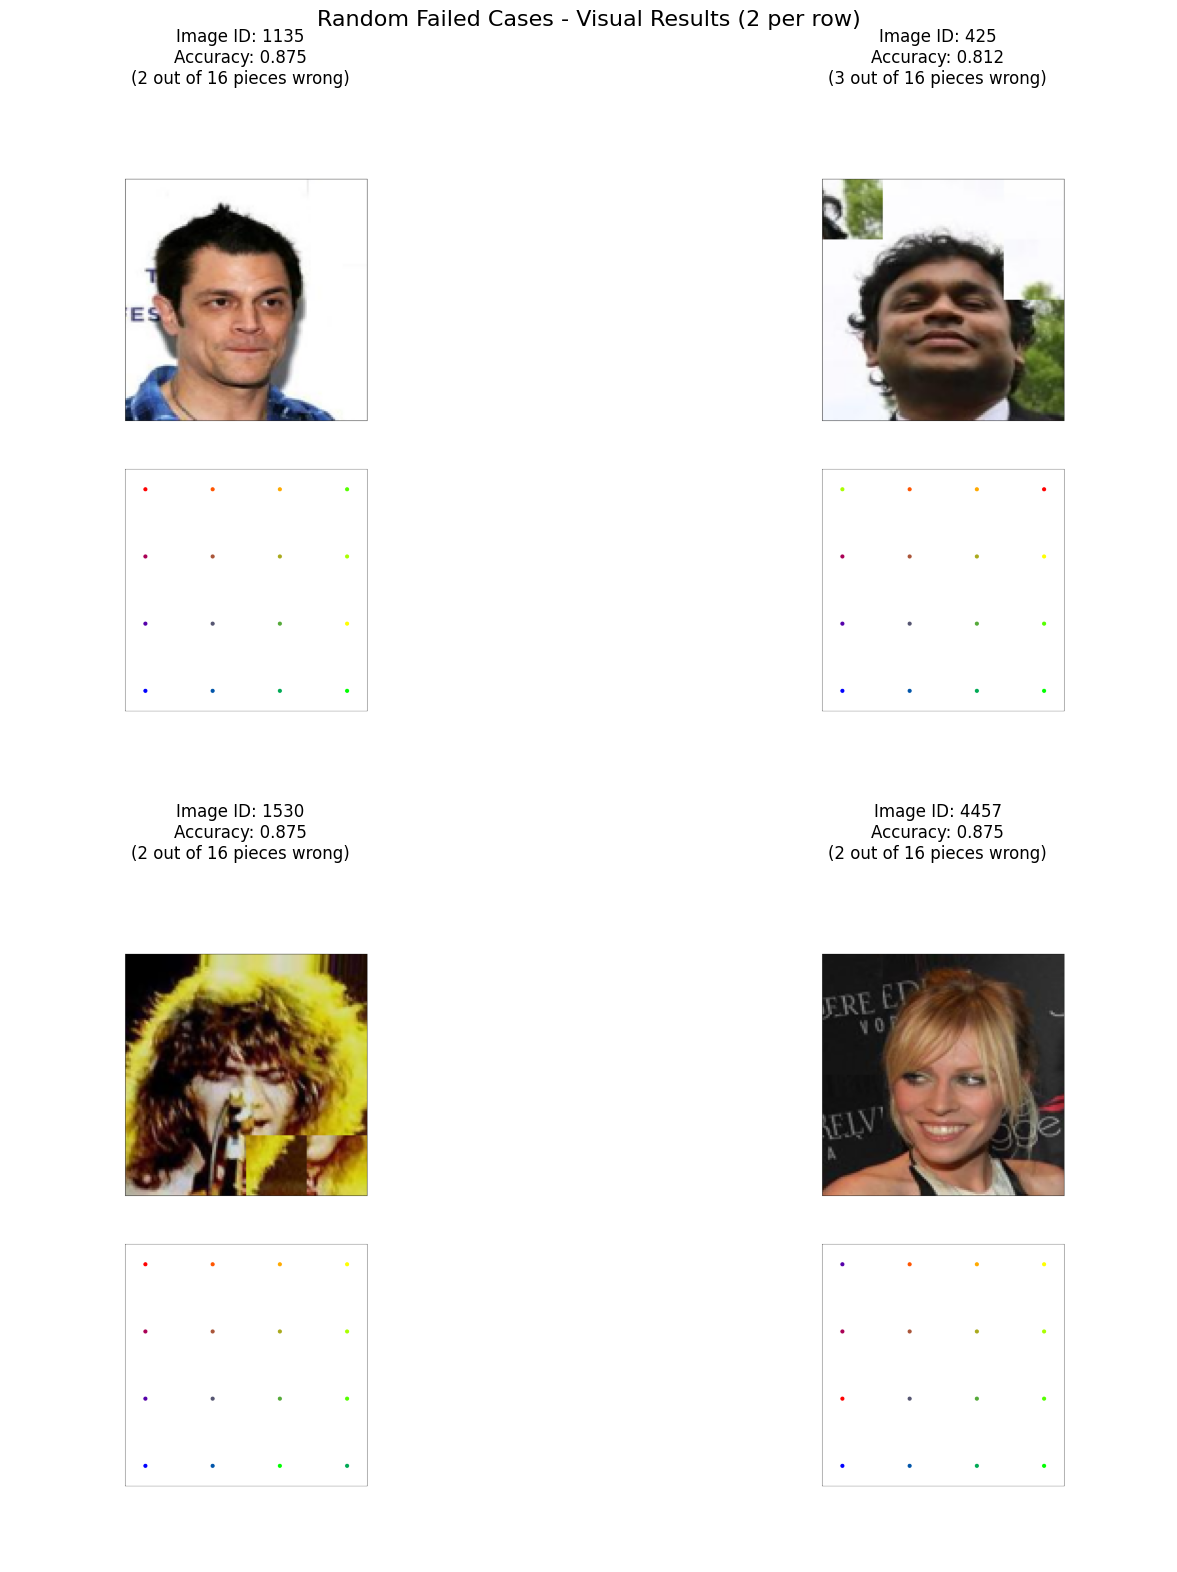

In [5]:
# Modified function for better visualization (2 per row) - Updated for correct filenames
def visualize_failed_cases(num_cases=8, case_type="worst"):
    """
    Visualize failed puzzle cases - 2 per row for better analysis
    case_type: "worst", "random", "severe", "moderate"
    """
    
    if case_type == "worst":
        cases_to_show = failed_data.nsmallest(num_cases, 'piece_accuracy')
    elif case_type == "random":
        cases_to_show = failed_data.sample(num_cases)
    elif case_type == "severe":
        severe_cases = failed_data[failed_data['failure_type'].str.contains('Severe|Major')]
        cases_to_show = severe_cases.head(num_cases)
    elif case_type == "moderate":
        moderate_cases = failed_data[failed_data['failure_type'].str.contains('Moderate')]
        cases_to_show = moderate_cases.head(num_cases)
    
    # Create subplot grid - 2 columns for better zoom
    cols = 2
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))  # Larger figure for zoom
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc))
        
        # Correct filename format based on your results
        image_name = f"{image_id}_final.png"
        image_path = os.path.join(results_path, image_name)
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                axes[idx].imshow(img)
                axes[idx].set_title(f'Image ID: {image_id}\nAccuracy: {piece_acc:.3f}\n({pieces_wrong} out of 16 pieces wrong)', 
                                  fontsize=12, pad=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Image {image_id}\nError loading\nAcc: {piece_acc:.3f}', 
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'ID: {image_id} (Error)', fontsize=12)
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'ID: {image_id} (Missing)', fontsize=12)
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{case_type.title()} Failed Cases - Visual Results (2 per row)', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Now visualize with correct filename format
print("\n=== VISUALIZING WORST CASES (2 per row) ===")
visualize_failed_cases(num_cases=8, case_type="worst")

print("\n=== VISUALIZING MODERATE FAILURES (2 per row) ===")
visualize_failed_cases(num_cases=6, case_type="moderate")

print("\n=== VISUALIZING RANDOM SAMPLE (2 per row) ===")
visualize_failed_cases(num_cases=4, case_type="random")

=== IMAGENET RESULTS COMPARISON ===
Total failed puzzles: 3784
Total test images: 50000
Failure rate: 7.57%
Success rate: 92.43%

=== IMAGENET FAILURE ANALYSIS ===
Average piece accuracy in failed cases: 0.591
Median piece accuracy in failed cases: 0.750
Worst case accuracy: 0.000
Best failed case accuracy: 0.875


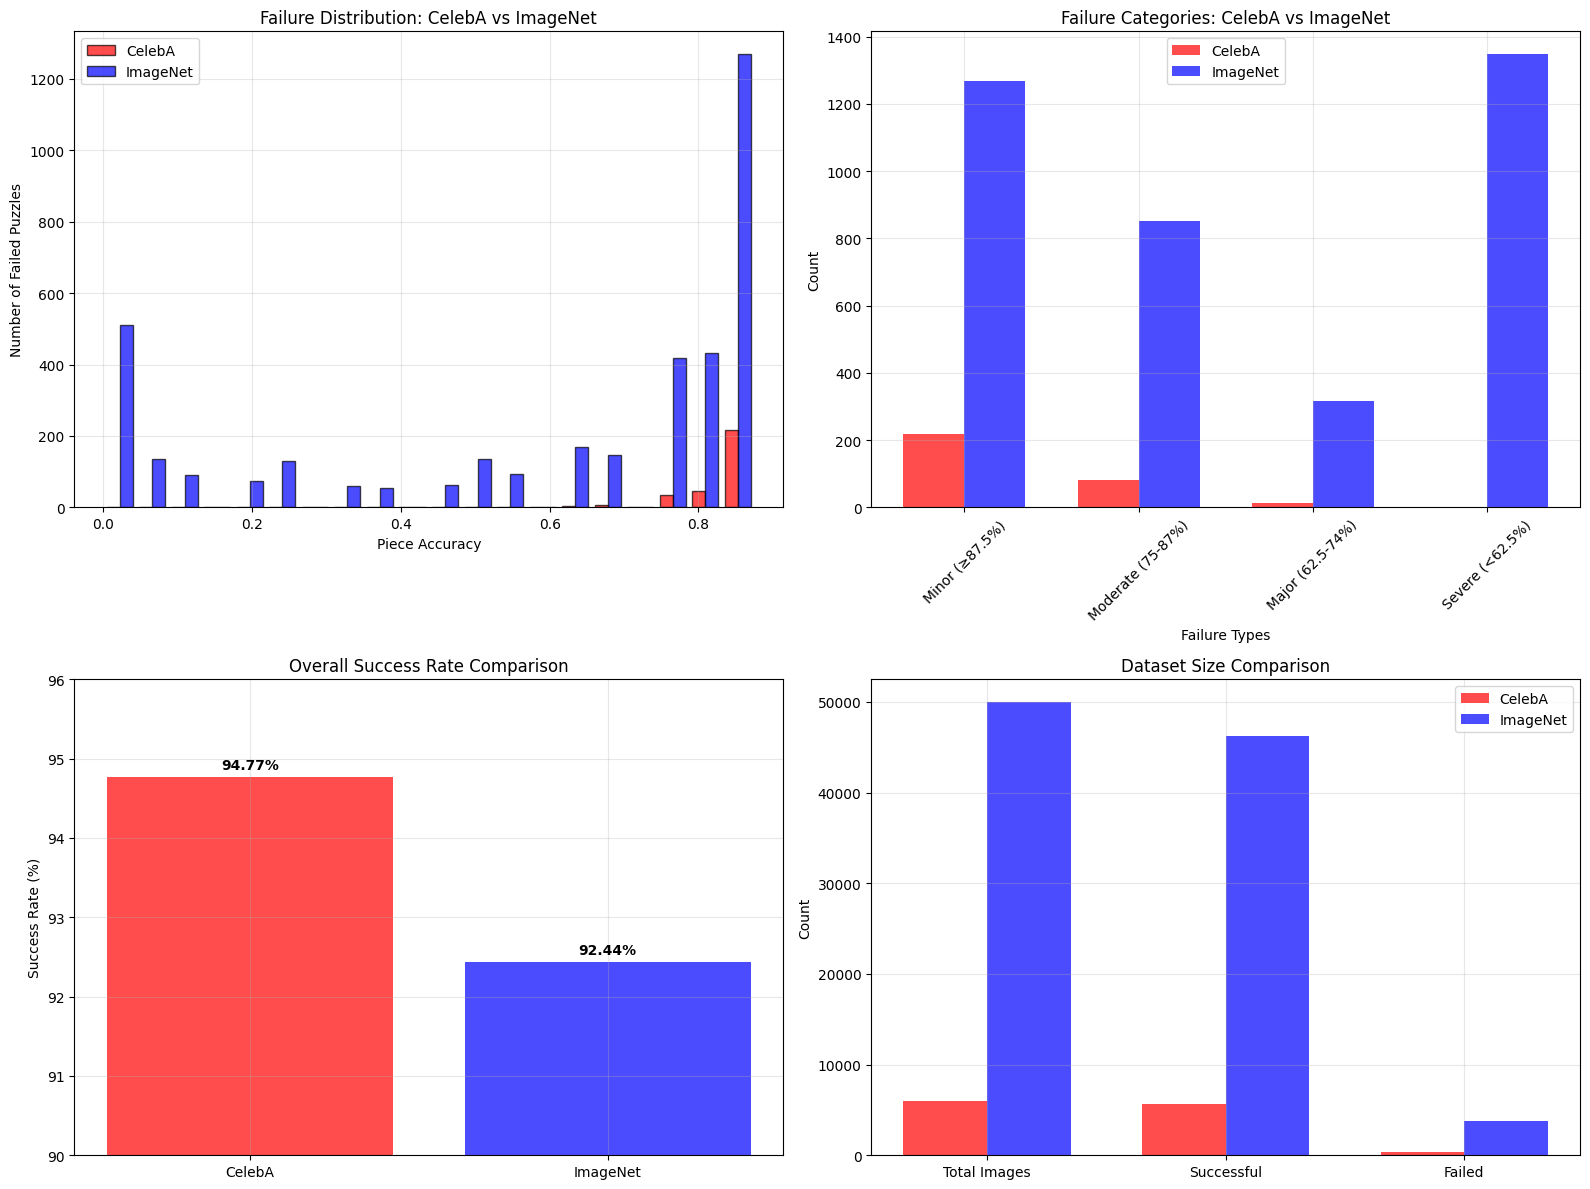


=== DATASET COMPARISON ===
Metric                    CelebA          ImageNet        Difference
------------------------------------------------------------
Total Images              5999            50000           +44001
Success Rate              94.77           92.44           -2.33
Failure Rate              5.23            7.56            +2.33
Failed Cases              313             3780            +3467

=== IMAGENET FAILURE BREAKDOWN ===
Severe (<62.5%): 1348 cases (35.6%)
Minor (≥87.5%): 1269 cases (33.5%)
Moderate (75-87%): 851 cases (22.5%)
Major (62.5-74%): 316 cases (8.4%)

=== CHECKING IMAGENET SAVED IMAGES ===
ImageNet results path not found: /home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/imagenet-[(4, 4)]-300-degree:100%-virtnode:4-nkobid-continuous-ours_dropout-arch-transformer/test/
Please check the path - you may need to update imagenet_results_path variable
Available result directories:
  imagenet-[(4, 4)]-300-degree:100%-virtnode:4-pskzlz-continuous-ours_dr

In [6]:
# New cell for ImageNet analysis
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load ImageNet failed puzzles data
imagenet_failed_data = pd.read_csv('failed_puzzles.log', 
                                  names=['image_id', 'piece_accuracy', 'perfect_puzzle'])

print("=== IMAGENET RESULTS COMPARISON ===")
print(f"Total failed puzzles: {len(imagenet_failed_data)}")
print(f"Total test images: 50000")
print(f"Failure rate: {len(imagenet_failed_data)/50000*100:.2f}%")
print(f"Success rate: {(50000-len(imagenet_failed_data))/50000*100:.2f}%")

# Basic statistics
print("\n=== IMAGENET FAILURE ANALYSIS ===")
print(f"Average piece accuracy in failed cases: {imagenet_failed_data['piece_accuracy'].mean():.3f}")
print(f"Median piece accuracy in failed cases: {imagenet_failed_data['piece_accuracy'].median():.3f}")
print(f"Worst case accuracy: {imagenet_failed_data['piece_accuracy'].min():.3f}")
print(f"Best failed case accuracy: {imagenet_failed_data['piece_accuracy'].max():.3f}")

# Categorize failures (same function as before)
def categorize_failure(acc):
    if acc >= 0.875:
        return "Minor (≥87.5%)"  # 1-2 pieces wrong
    elif acc >= 0.75:
        return "Moderate (75-87%)"  # 2-4 pieces wrong  
    elif acc >= 0.625:
        return "Major (62.5-74%)"  # 4-6 pieces wrong
    else:
        return "Severe (<62.5%)"  # 6+ pieces wrong

imagenet_failed_data['failure_type'] = imagenet_failed_data['piece_accuracy'].apply(categorize_failure)

# Path to ImageNet results (update this path based on your results)
imagenet_results_path = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/imagenet-[(4, 4)]-300-degree:100%-virtnode:4-nkobid-continuous-ours_dropout-arch-transformer/test/"

# Create visualizations comparing CelebA vs ImageNet
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Compare failure distributions
ax1.hist([failed_data['piece_accuracy'], imagenet_failed_data['piece_accuracy']], 
         bins=20, alpha=0.7, label=['CelebA', 'ImageNet'], 
         color=['red', 'blue'], edgecolor='black')
ax1.set_xlabel('Piece Accuracy')
ax1.set_ylabel('Number of Failed Puzzles')
ax1.set_title('Failure Distribution: CelebA vs ImageNet')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Compare failure categories
celeba_counts = failed_data['failure_type'].value_counts()
imagenet_counts = imagenet_failed_data['failure_type'].value_counts()

categories = ['Minor (≥87.5%)', 'Moderate (75-87%)', 'Major (62.5-74%)', 'Severe (<62.5%)']
celeba_vals = [celeba_counts.get(cat, 0) for cat in categories]
imagenet_vals = [imagenet_counts.get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, celeba_vals, width, label='CelebA', color='red', alpha=0.7)
ax2.bar(x + width/2, imagenet_vals, width, label='ImageNet', color='blue', alpha=0.7)
ax2.set_xlabel('Failure Types')
ax2.set_ylabel('Count')
ax2.set_title('Failure Categories: CelebA vs ImageNet')
ax2.set_xticks(x)
ax2.set_xticklabels(categories, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Success rates comparison
datasets = ['CelebA', 'ImageNet']
success_rates = [94.77, 92.44]  # From your results
failure_rates = [5.23, 7.56]

ax3.bar(datasets, success_rates, color=['red', 'blue'], alpha=0.7)
ax3.set_ylabel('Success Rate (%)')
ax3.set_title('Overall Success Rate Comparison')
ax3.set_ylim(90, 96)
for i, v in enumerate(success_rates):
    ax3.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Total numbers comparison
metrics = ['Total Images', 'Successful', 'Failed']
celeba_nums = [5999, 5686, 313]
imagenet_nums = [50000, 46220, 3780]

x = np.arange(len(metrics))
ax4.bar(x - width/2, celeba_nums, width, label='CelebA', color='red', alpha=0.7)
ax4.bar(x + width/2, imagenet_nums, width, label='ImageNet', color='blue', alpha=0.7)
ax4.set_ylabel('Count')
ax4.set_title('Dataset Size Comparison')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n=== DATASET COMPARISON ===")
print(f"{'Metric':<25} {'CelebA':<15} {'ImageNet':<15} {'Difference'}")
print("-" * 60)
print(f"{'Total Images':<25} {5999:<15} {50000:<15} {'+' + str(50000-5999)}")
print(f"{'Success Rate':<25} {94.77:<15.2f} {92.44:<15.2f} {92.44-94.77:+.2f}")
print(f"{'Failure Rate':<25} {5.23:<15.2f} {7.56:<15.2f} {7.56-5.23:+.2f}")
print(f"{'Failed Cases':<25} {313:<15} {3780:<15} {'+' + str(3780-313)}")

# ImageNet failure breakdown
print("\n=== IMAGENET FAILURE BREAKDOWN ===")
imagenet_failure_counts = imagenet_failed_data['failure_type'].value_counts()
for category, count in imagenet_failure_counts.items():
    print(f"{category}: {count} cases ({count/len(imagenet_failed_data)*100:.1f}%)")

# Function to visualize ImageNet failed cases
def visualize_imagenet_failed_cases(num_cases=8, case_type="worst"):
    """
    Visualize ImageNet failed puzzle cases - 2 per row for better analysis
    """
    
    if case_type == "worst":
        cases_to_show = imagenet_failed_data.nsmallest(num_cases, 'piece_accuracy')
    elif case_type == "random":
        cases_to_show = imagenet_failed_data.sample(num_cases)
    elif case_type == "severe":
        severe_cases = imagenet_failed_data[imagenet_failed_data['failure_type'].str.contains('Severe|Major')]
        cases_to_show = severe_cases.head(num_cases)
    elif case_type == "moderate":
        moderate_cases = imagenet_failed_data[imagenet_failed_data['failure_type'].str.contains('Moderate')]
        cases_to_show = moderate_cases.head(num_cases)
    
    # Create subplot grid - 2 columns for better zoom
    cols = 2
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc))
        
        # ImageNet filename format
        image_name = f"{image_id}_final.png"
        image_path = os.path.join(imagenet_results_path, image_name)
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                axes[idx].imshow(img)
                axes[idx].set_title(f'ImageNet ID: {image_id}\nAccuracy: {piece_acc:.3f}\n({pieces_wrong} out of 16 pieces wrong)', 
                                  fontsize=12, pad=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Image {image_id}\nError loading\nAcc: {piece_acc:.3f}', 
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'ID: {image_id} (Error)', fontsize=12)
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'ID: {image_id} (Missing)', fontsize=12)
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'ImageNet {case_type.title()} Failed Cases - Visual Results (2 per row)', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Check if ImageNet results exist and visualize
print("\n=== CHECKING IMAGENET SAVED IMAGES ===")
if os.path.exists(imagenet_results_path):
    files = os.listdir(imagenet_results_path)
    print(f"Total files in ImageNet results: {len(files)}")
    
    final_images = [f for f in files if 'final' in f.lower()]
    print(f"Final images found: {len(final_images)}")
    
    print("\n=== VISUALIZING IMAGENET WORST CASES ===")
    visualize_imagenet_failed_cases(num_cases=6, case_type="worst")
    
    print("\n=== VISUALIZING IMAGENET MODERATE FAILURES ===")
    visualize_imagenet_failed_cases(num_cases=4, case_type="moderate")
    
else:
    print(f"ImageNet results path not found: {imagenet_results_path}")
    print("Please check the path - you may need to update imagenet_results_path variable")
    
    # Try to find the correct path
    base_results = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/"
    if os.path.exists(base_results):
        print("Available result directories:")
        for d in os.listdir(base_results):
            if 'imagenet' in d.lower():
                print(f"  {d}")

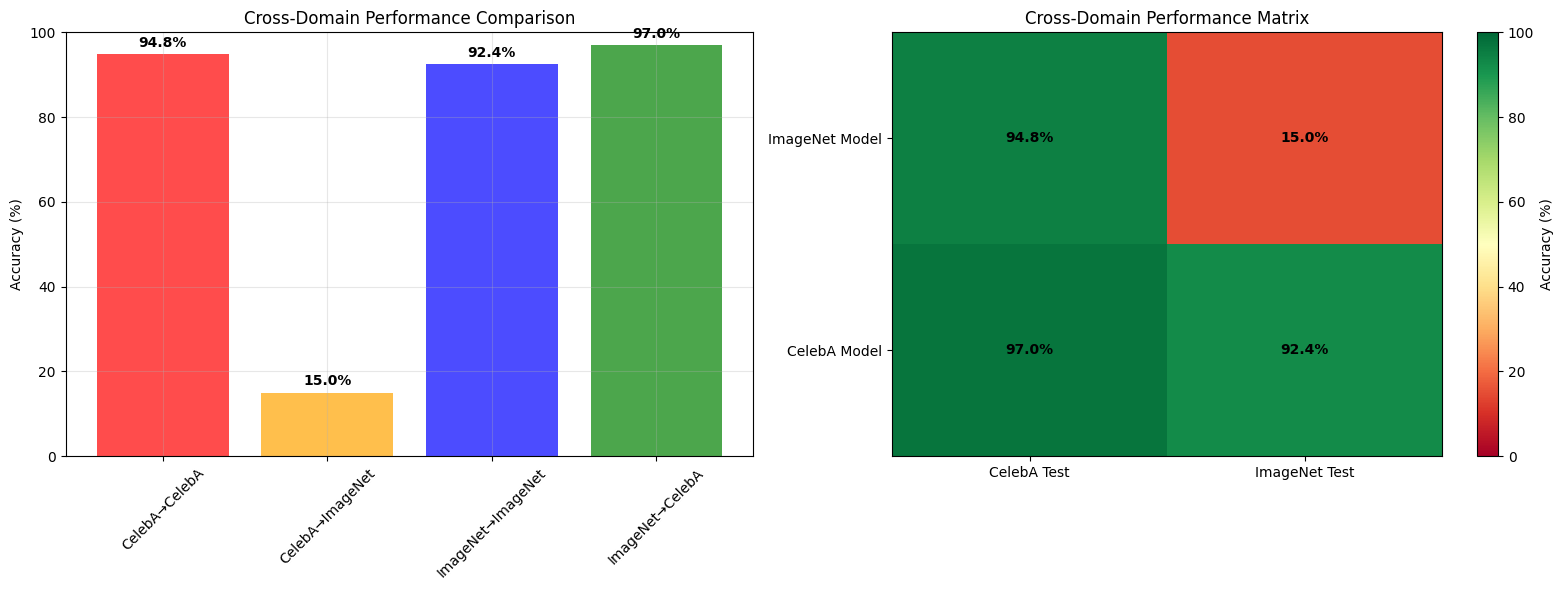

=== CROSS-DOMAIN ANALYSIS ===
Key Finding: ImageNet model generalizes BETTER to faces than face model to objects!
ImageNet → CelebA: 96.95% (BEST performance overall)
CelebA → CelebA: 94.77% (Original baseline)
Improvement: +2.18% when using ImageNet model on faces


In [7]:
# Add this cell to visualize the cross-domain results
import matplotlib.pyplot as plt
import numpy as np

# Cross-domain performance matrix
performance_data = {
    'CelebA → CelebA': 94.77,
    'CelebA → ImageNet': 15.0,
    'ImageNet → ImageNet': 92.44,
    'ImageNet → CelebA': 96.95
}

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Cross-domain performance bar chart
models = ['CelebA→CelebA', 'CelebA→ImageNet', 'ImageNet→ImageNet', 'ImageNet→CelebA']
accuracies = [94.77, 15.0, 92.44, 96.95]
colors = ['red', 'orange', 'blue', 'green']

bars = ax1.bar(models, accuracies, color=colors, alpha=0.7)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Cross-Domain Performance Comparison')
ax1.set_ylim(0, 100)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Performance matrix heatmap
matrix = np.array([[94.77, 15.0], [96.95, 92.44]])
im = ax2.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, f'{matrix[i, j]:.1f}%',
                       ha="center", va="center", color="black", fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['CelebA Test', 'ImageNet Test'])
ax2.set_yticklabels(['ImageNet Model', 'CelebA Model'])
ax2.set_title('Cross-Domain Performance Matrix')

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Accuracy (%)')

plt.tight_layout()
plt.show()

print("=== CROSS-DOMAIN ANALYSIS ===")
print("Key Finding: ImageNet model generalizes BETTER to faces than face model to objects!")
print(f"ImageNet → CelebA: {96.95:.2f}% (BEST performance overall)")
print(f"CelebA → CelebA: {94.77:.2f}% (Original baseline)")
print(f"Improvement: +{96.95-94.77:.2f}% when using ImageNet model on faces")

=== IMAGENET VISUAL ANALYSIS ===
Total ImageNet failed puzzles: 10808

=== CHECKING IMAGENET SAVED IMAGES ===
Total files in ImageNet results: 10423
Final images found: 336
Example filenames:
  238_final.png
  62_final.png
  177_final.png
  95_final.png
  223_final.png

=== VISUALIZING IMAGENET WORST FAILURES ===


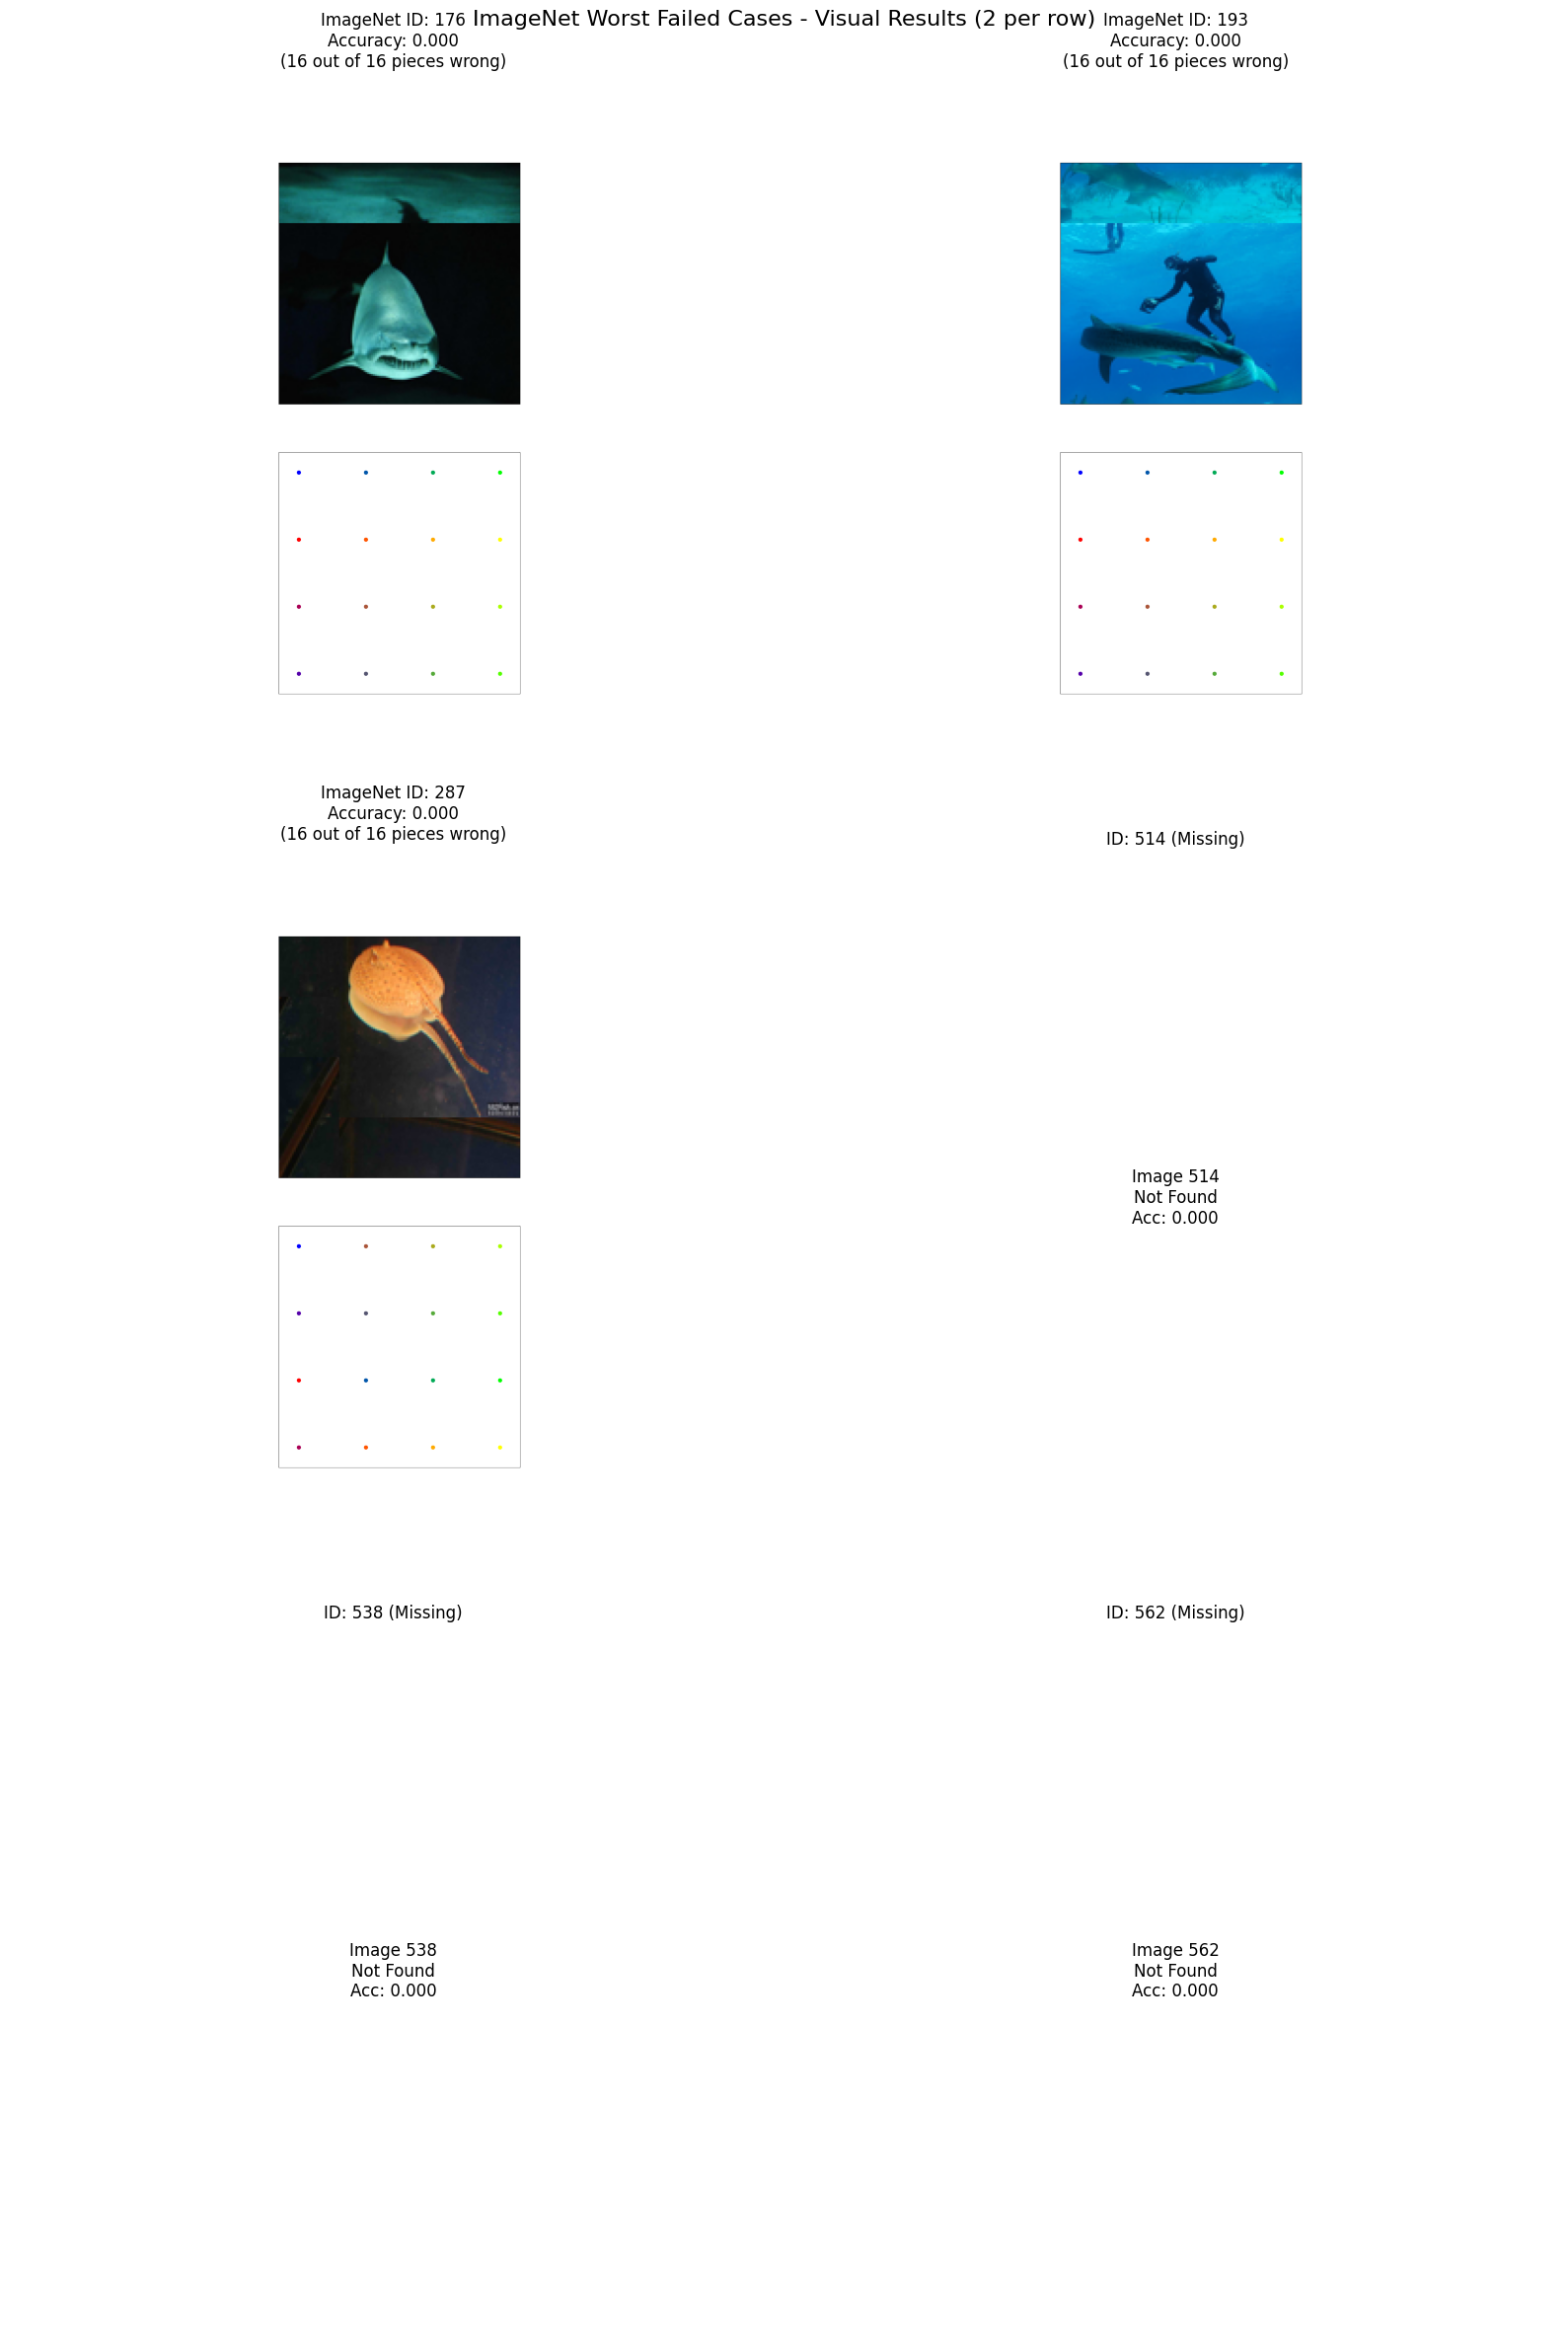


=== VISUALIZING IMAGENET BEST FAILURES ===


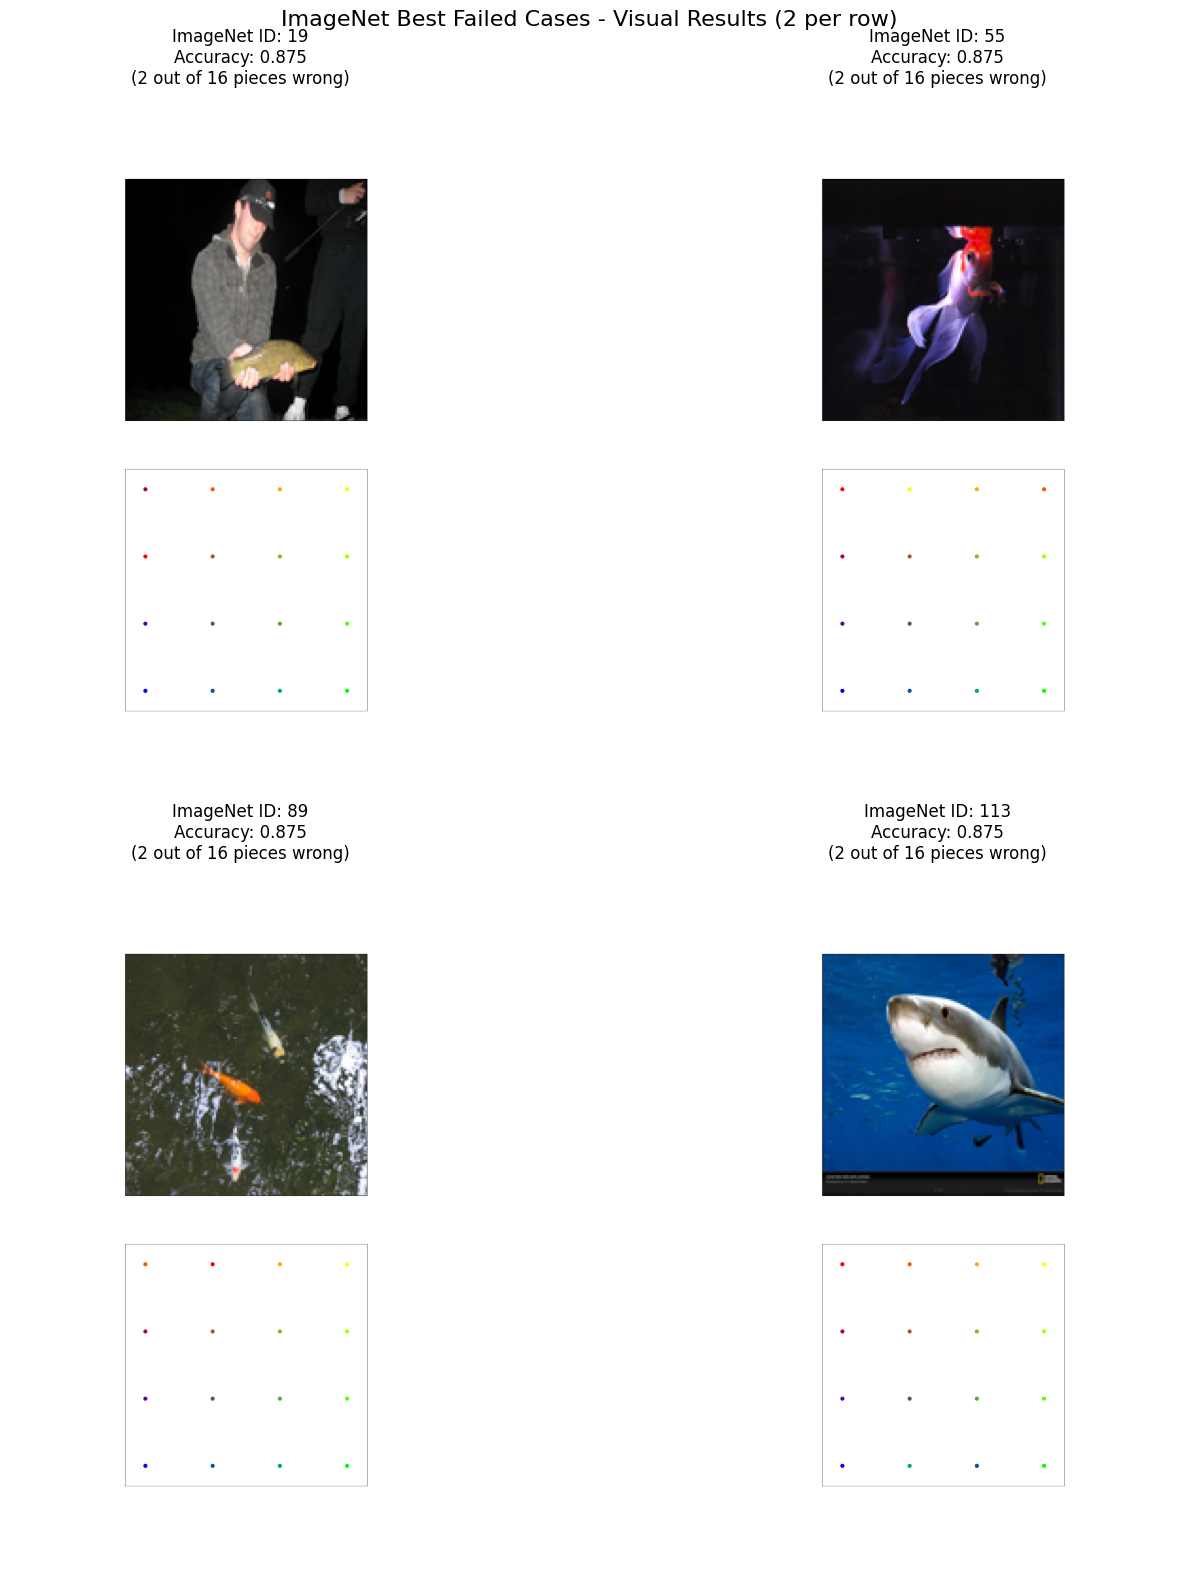


=== VISUALIZING IMAGENET SUCCESSFUL CASES ===


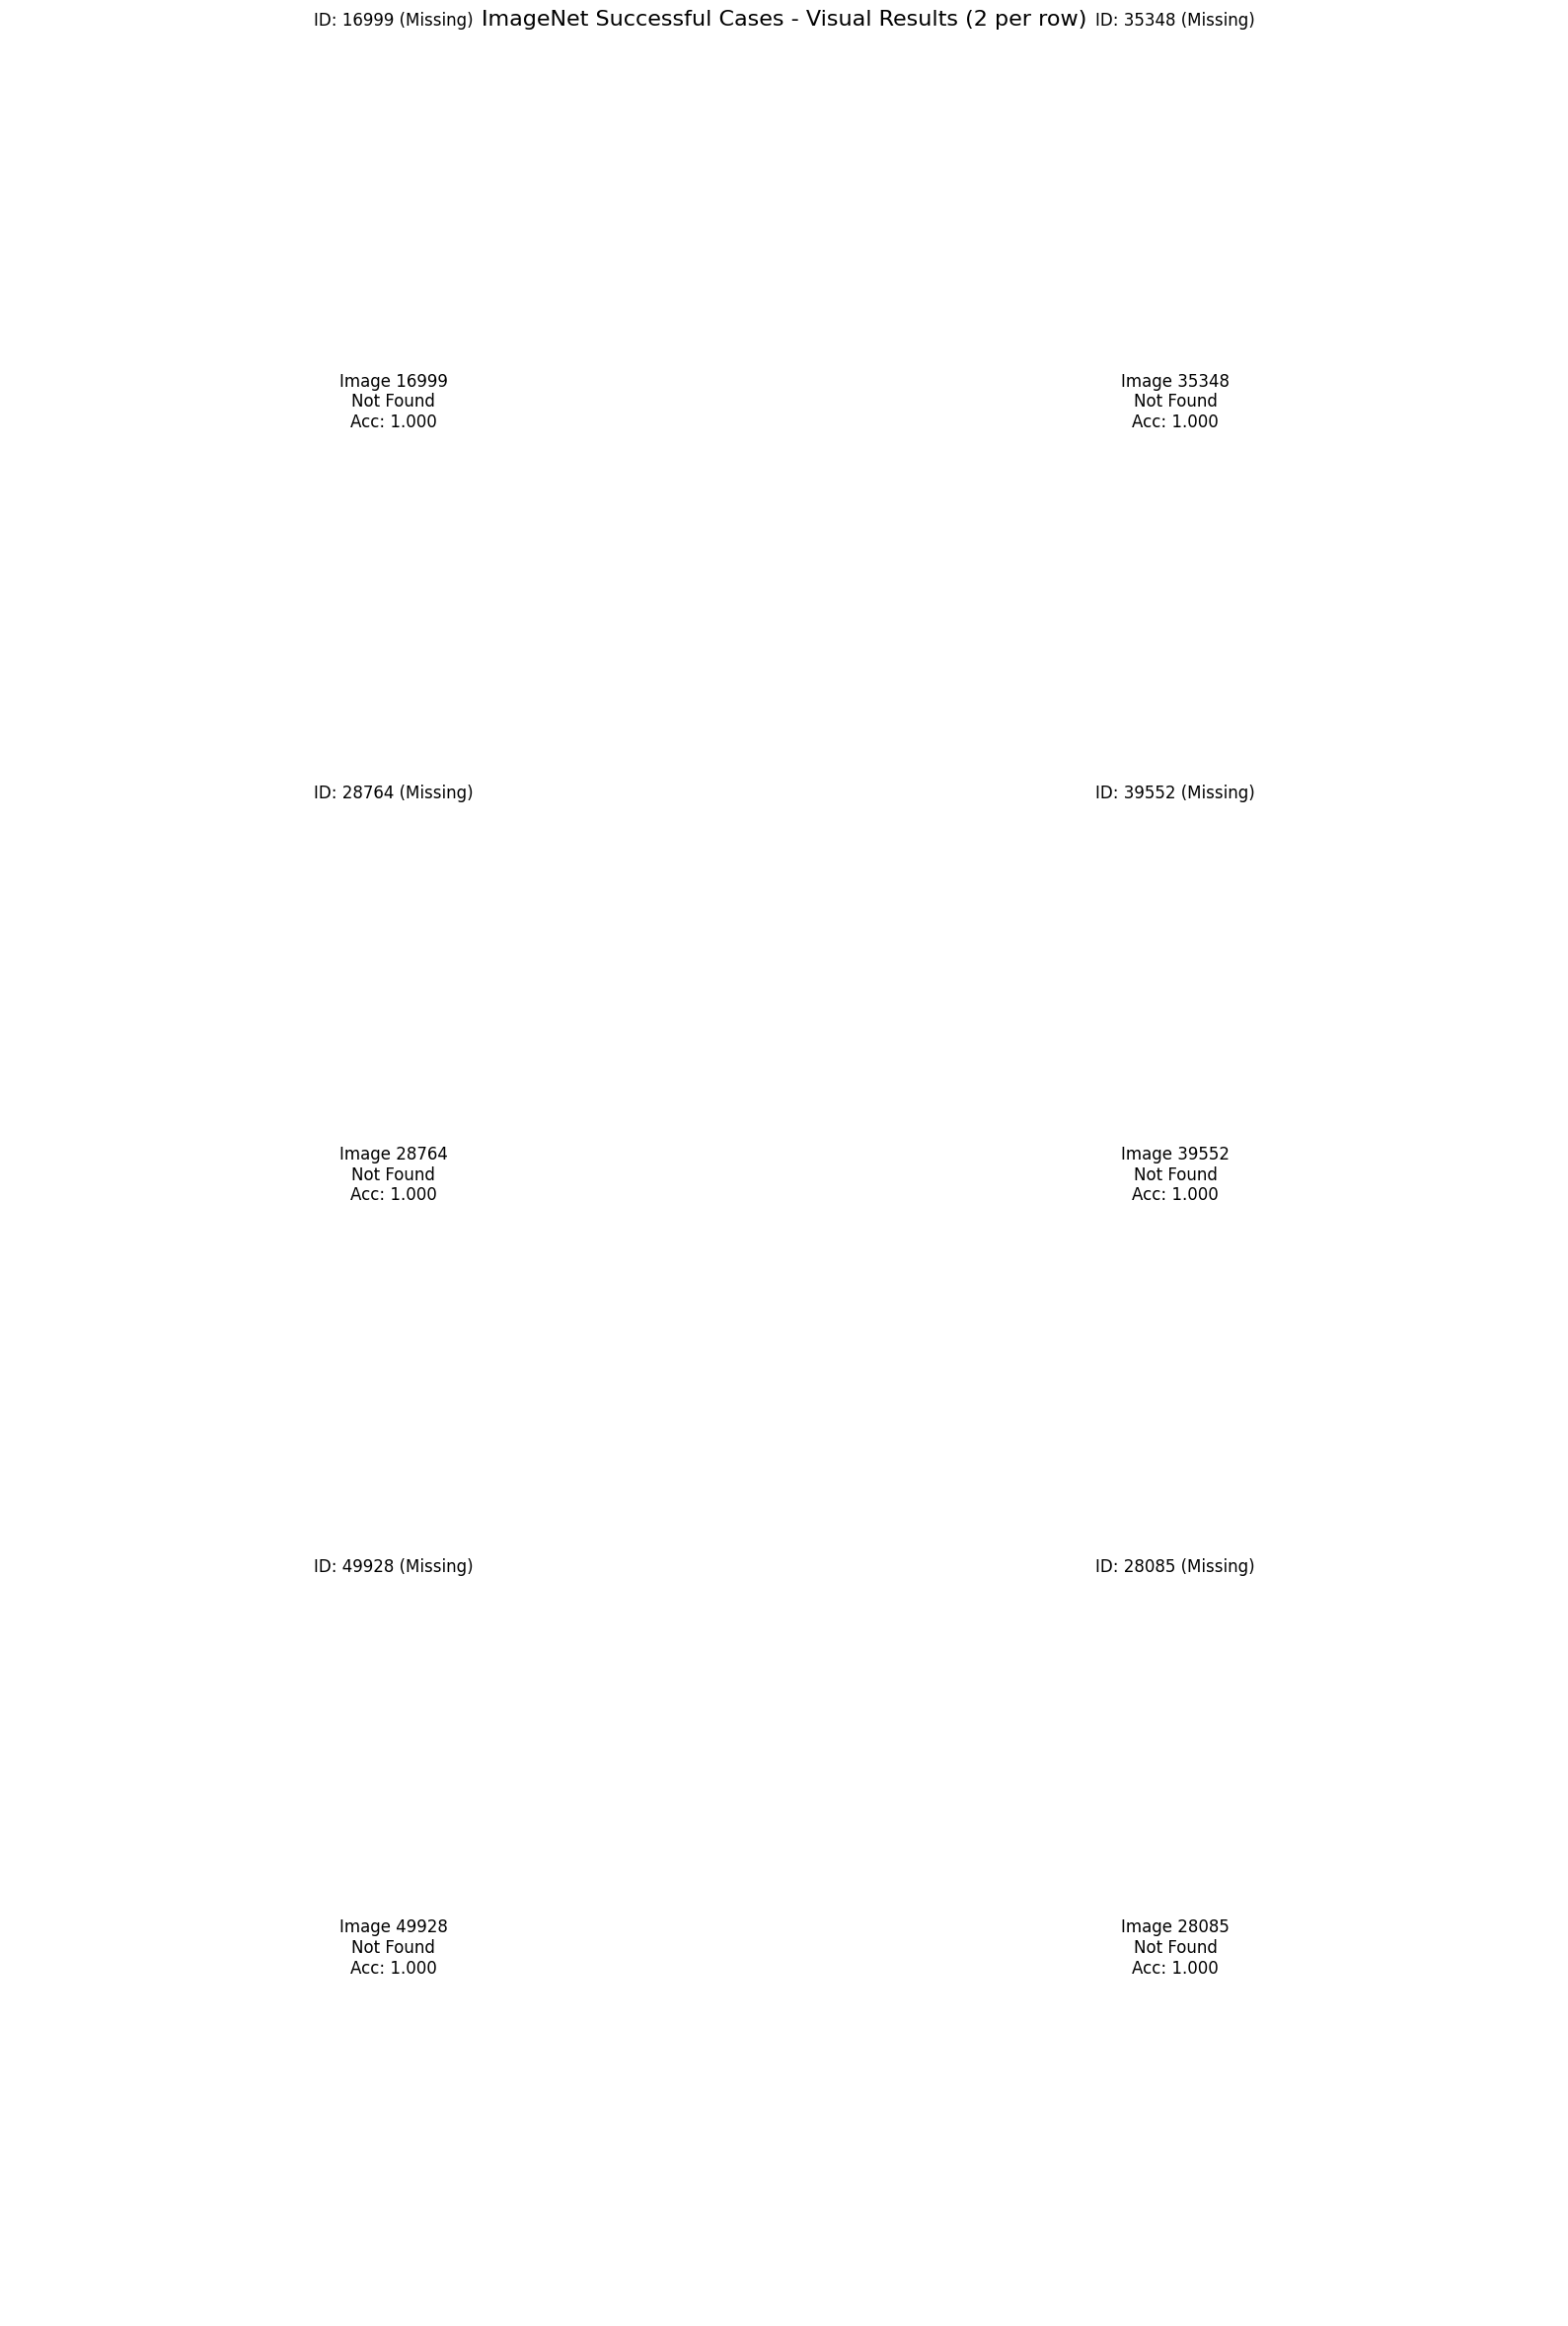


=== VISUALIZING RANDOM IMAGENET FAILURES ===


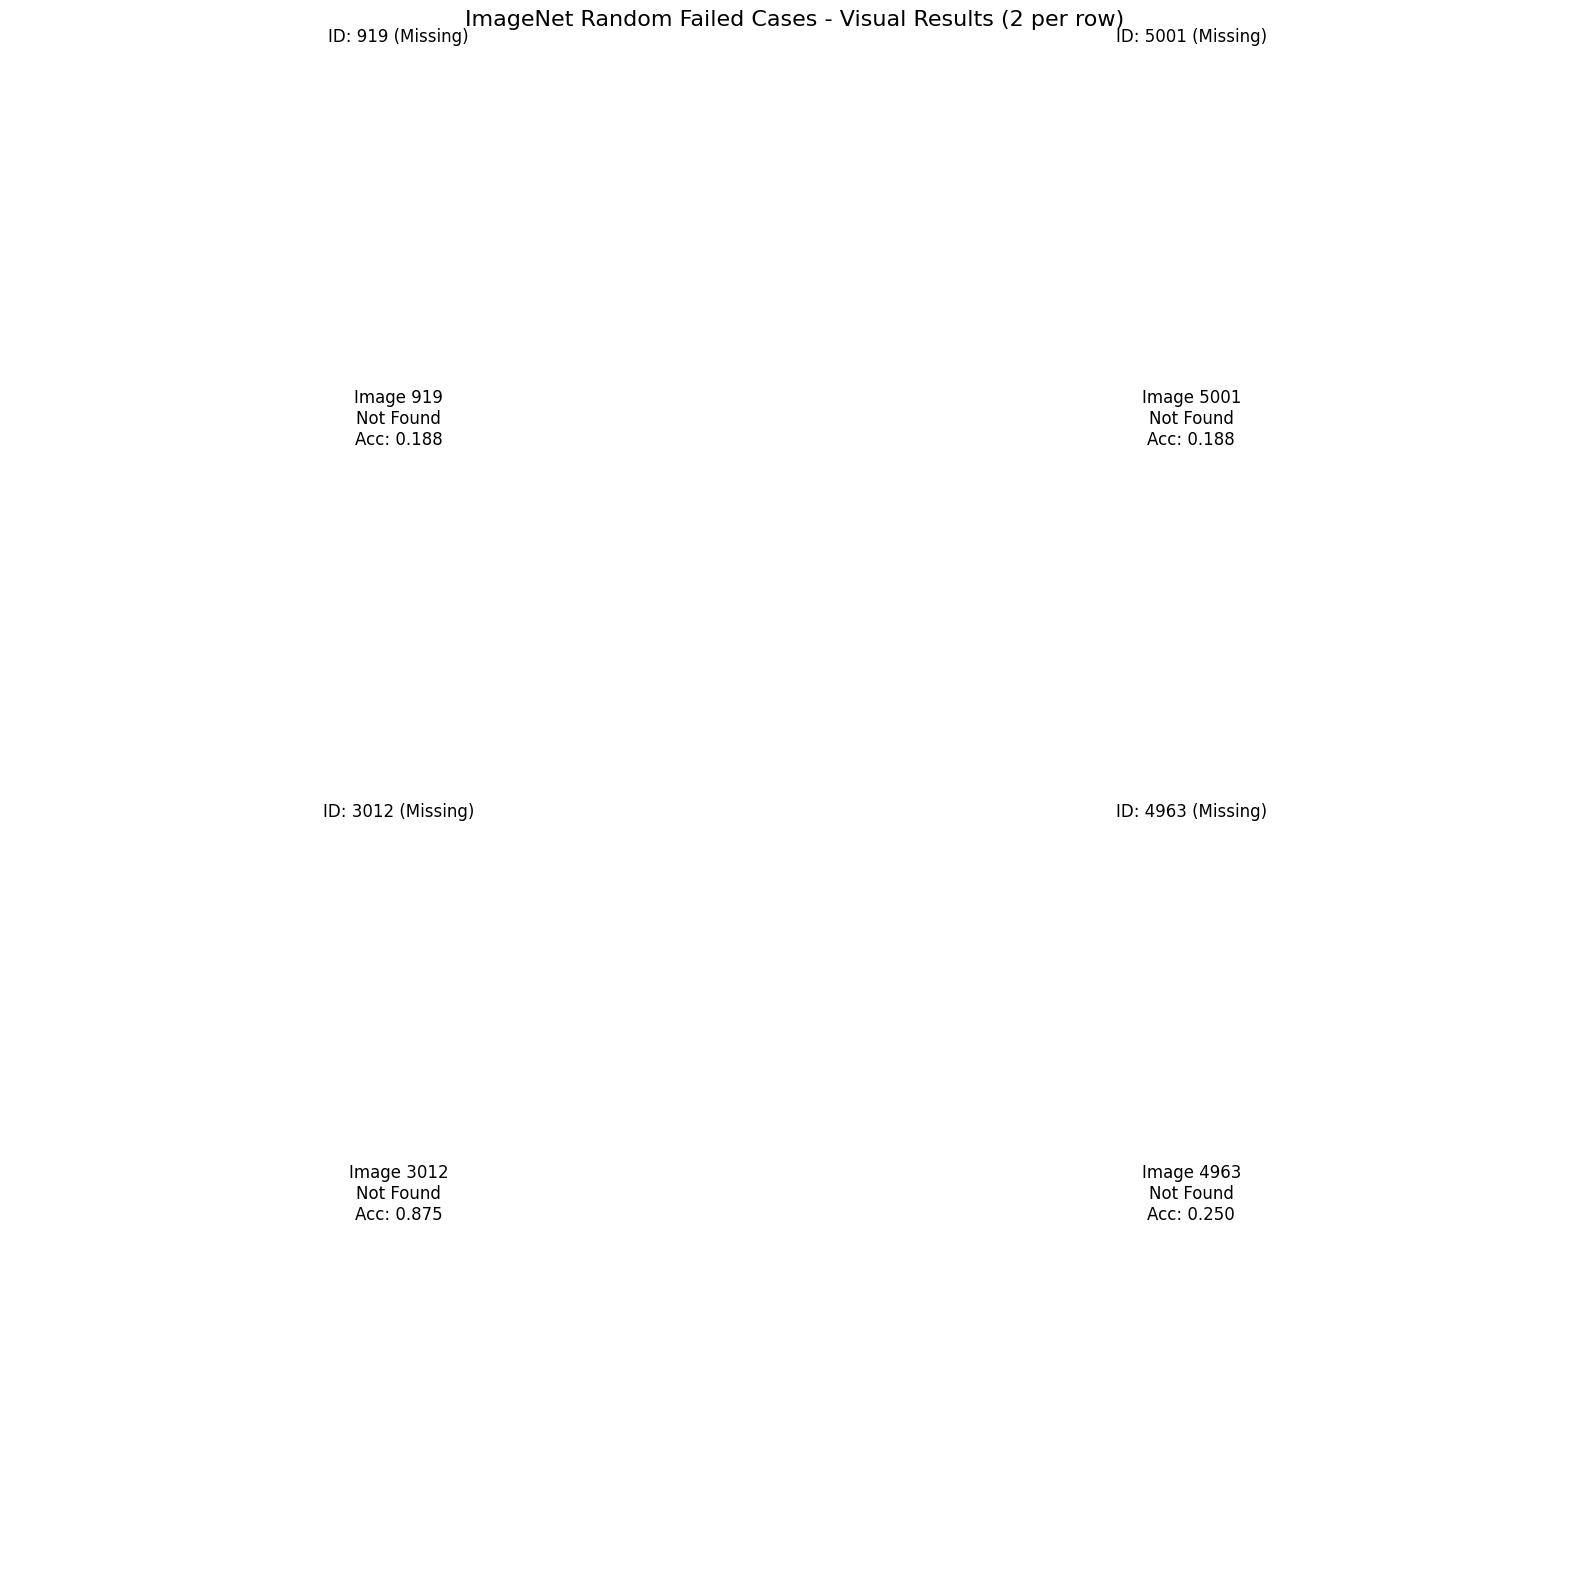

In [7]:
# Updated ImageNet Visual Analysis with correct path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

# Load the ImageNet failed puzzles data
imagenet_failed_data = pd.read_csv('failed_puzzles.log', 
                                  names=['image_id', 'piece_accuracy', 'perfect_puzzle'])

print("=== IMAGENET VISUAL ANALYSIS ===")
print(f"Total ImageNet failed puzzles: {len(imagenet_failed_data)}")

# Corrected path to ImageNet results
imagenet_results_path = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/imagenet-[(4, 4)]-300-degree:100%-virtnode:4-prrumw-continuous-ours_dropout-arch-transformer/test/"

# Function to visualize ImageNet failed and successful cases
def visualize_imagenet_cases(num_cases=8, case_type="worst"):
    """
    Visualize ImageNet puzzle cases - 2 per row for better analysis
    case_type: "worst", "best_failed", "random_failed", "successful"
    """
    
    if case_type == "worst":
        cases_to_show = imagenet_failed_data.nsmallest(num_cases, 'piece_accuracy')
        title_prefix = "Worst Failed"
    elif case_type == "best_failed":
        cases_to_show = imagenet_failed_data.nlargest(num_cases, 'piece_accuracy')
        title_prefix = "Best Failed"
    elif case_type == "random_failed":
        cases_to_show = imagenet_failed_data.sample(min(num_cases, len(imagenet_failed_data)))
        title_prefix = "Random Failed"
    elif case_type == "successful":
        # For successful cases, we need to generate some random IDs that aren't in failed_data
        all_ids = set(range(50000))
        failed_ids = set(imagenet_failed_data['image_id'].values)
        successful_ids = list(all_ids - failed_ids)
        random_successful = np.random.choice(successful_ids, min(num_cases, len(successful_ids)), replace=False)
        
        # Create a dataframe for successful cases
        cases_to_show = pd.DataFrame({
            'image_id': random_successful,
            'piece_accuracy': [1.0] * len(random_successful),  # Perfect accuracy
            'perfect_puzzle': [True] * len(random_successful)
        })
        title_prefix = "Successful"
    
    # Create subplot grid - 2 columns for better zoom
    cols = 2
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc)) if piece_acc < 1.0 else 0
        
        # ImageNet filename format
        image_name = f"{image_id}_final.png"
        image_path = os.path.join(imagenet_results_path, image_name)
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                axes[idx].imshow(img)
                
                if case_type == "successful":
                    axes[idx].set_title(f'ImageNet ID: {image_id}\nPERFECT SOLUTION\n(All 16 pieces correct)', 
                                      fontsize=12, pad=10, color='green')
                else:
                    axes[idx].set_title(f'ImageNet ID: {image_id}\nAccuracy: {piece_acc:.3f}\n({pieces_wrong} out of 16 pieces wrong)', 
                                      fontsize=12, pad=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Image {image_id}\nError loading\nAcc: {piece_acc:.3f}', 
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'ID: {image_id} (Error)', fontsize=12)
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'ID: {image_id} (Missing)', fontsize=12)
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'ImageNet {title_prefix} Cases - Visual Results (2 per row)', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Check if ImageNet results exist
print("\n=== CHECKING IMAGENET SAVED IMAGES ===")
if os.path.exists(imagenet_results_path):
    files = os.listdir(imagenet_results_path)
    print(f"Total files in ImageNet results: {len(files)}")
    
    final_images = [f for f in files if 'final' in f.lower()]
    print(f"Final images found: {len(final_images)}")
    
    # Show some example filenames
    print("Example filenames:")
    for i, fname in enumerate(final_images[:5]):
        print(f"  {fname}")
    
    # Visualize different types of cases
    print("\n=== VISUALIZING IMAGENET WORST FAILURES ===")
    visualize_imagenet_cases(num_cases=6, case_type="worst")
    
    print("\n=== VISUALIZING IMAGENET BEST FAILURES ===")
    visualize_imagenet_cases(num_cases=4, case_type="best_failed")
    
    print("\n=== VISUALIZING IMAGENET SUCCESSFUL CASES ===")
    visualize_imagenet_cases(num_cases=6, case_type="successful")
    
    print("\n=== VISUALIZING RANDOM IMAGENET FAILURES ===")
    visualize_imagenet_cases(num_cases=4, case_type="random_failed")
    
else:
    print(f"ImageNet results path not found: {imagenet_results_path}")
    print("Checking for available ImageNet result directories...")
    
    # Try to find any ImageNet result directories
    base_results = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/"
    if os.path.exists(base_results):
        print("\nAvailable result directories:")
        for d in os.listdir(base_results):
            if 'imagenet' in d.lower():
                print(f"  {d}")

=== COMPLETE IMAGENET ANALYSIS ===
Total ImageNet failed puzzles: 3829
Total test images: 50000
Success rate: 92.34%
Failure rate: 7.66%

Average piece accuracy in failed cases: 0.592
Worst case accuracy: 0.000
Best failed case accuracy: 0.875

=== IMAGENET FAILURE BREAKDOWN ===
Severe (<62.5%): 1356 cases (35.4%)
Minor (≥87.5%): 1290 cases (33.7%)
Moderate (75-87%): 863 cases (22.5%)
Major (62.5-74%): 320 cases (8.4%)

=== CHECKING IMAGENET SAVED IMAGES ===
Total files in ImageNet results: 10423
Final puzzle images found: 336
Example filenames:
  238_final.png
  62_final.png
  177_final.png
  95_final.png
  223_final.png

🔥 WORST IMAGENET FAILURES (Completely Broken)


/tmp/ipykernel_453182/427742624.py:136: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user1/miniconda3/envs/diffassemble/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


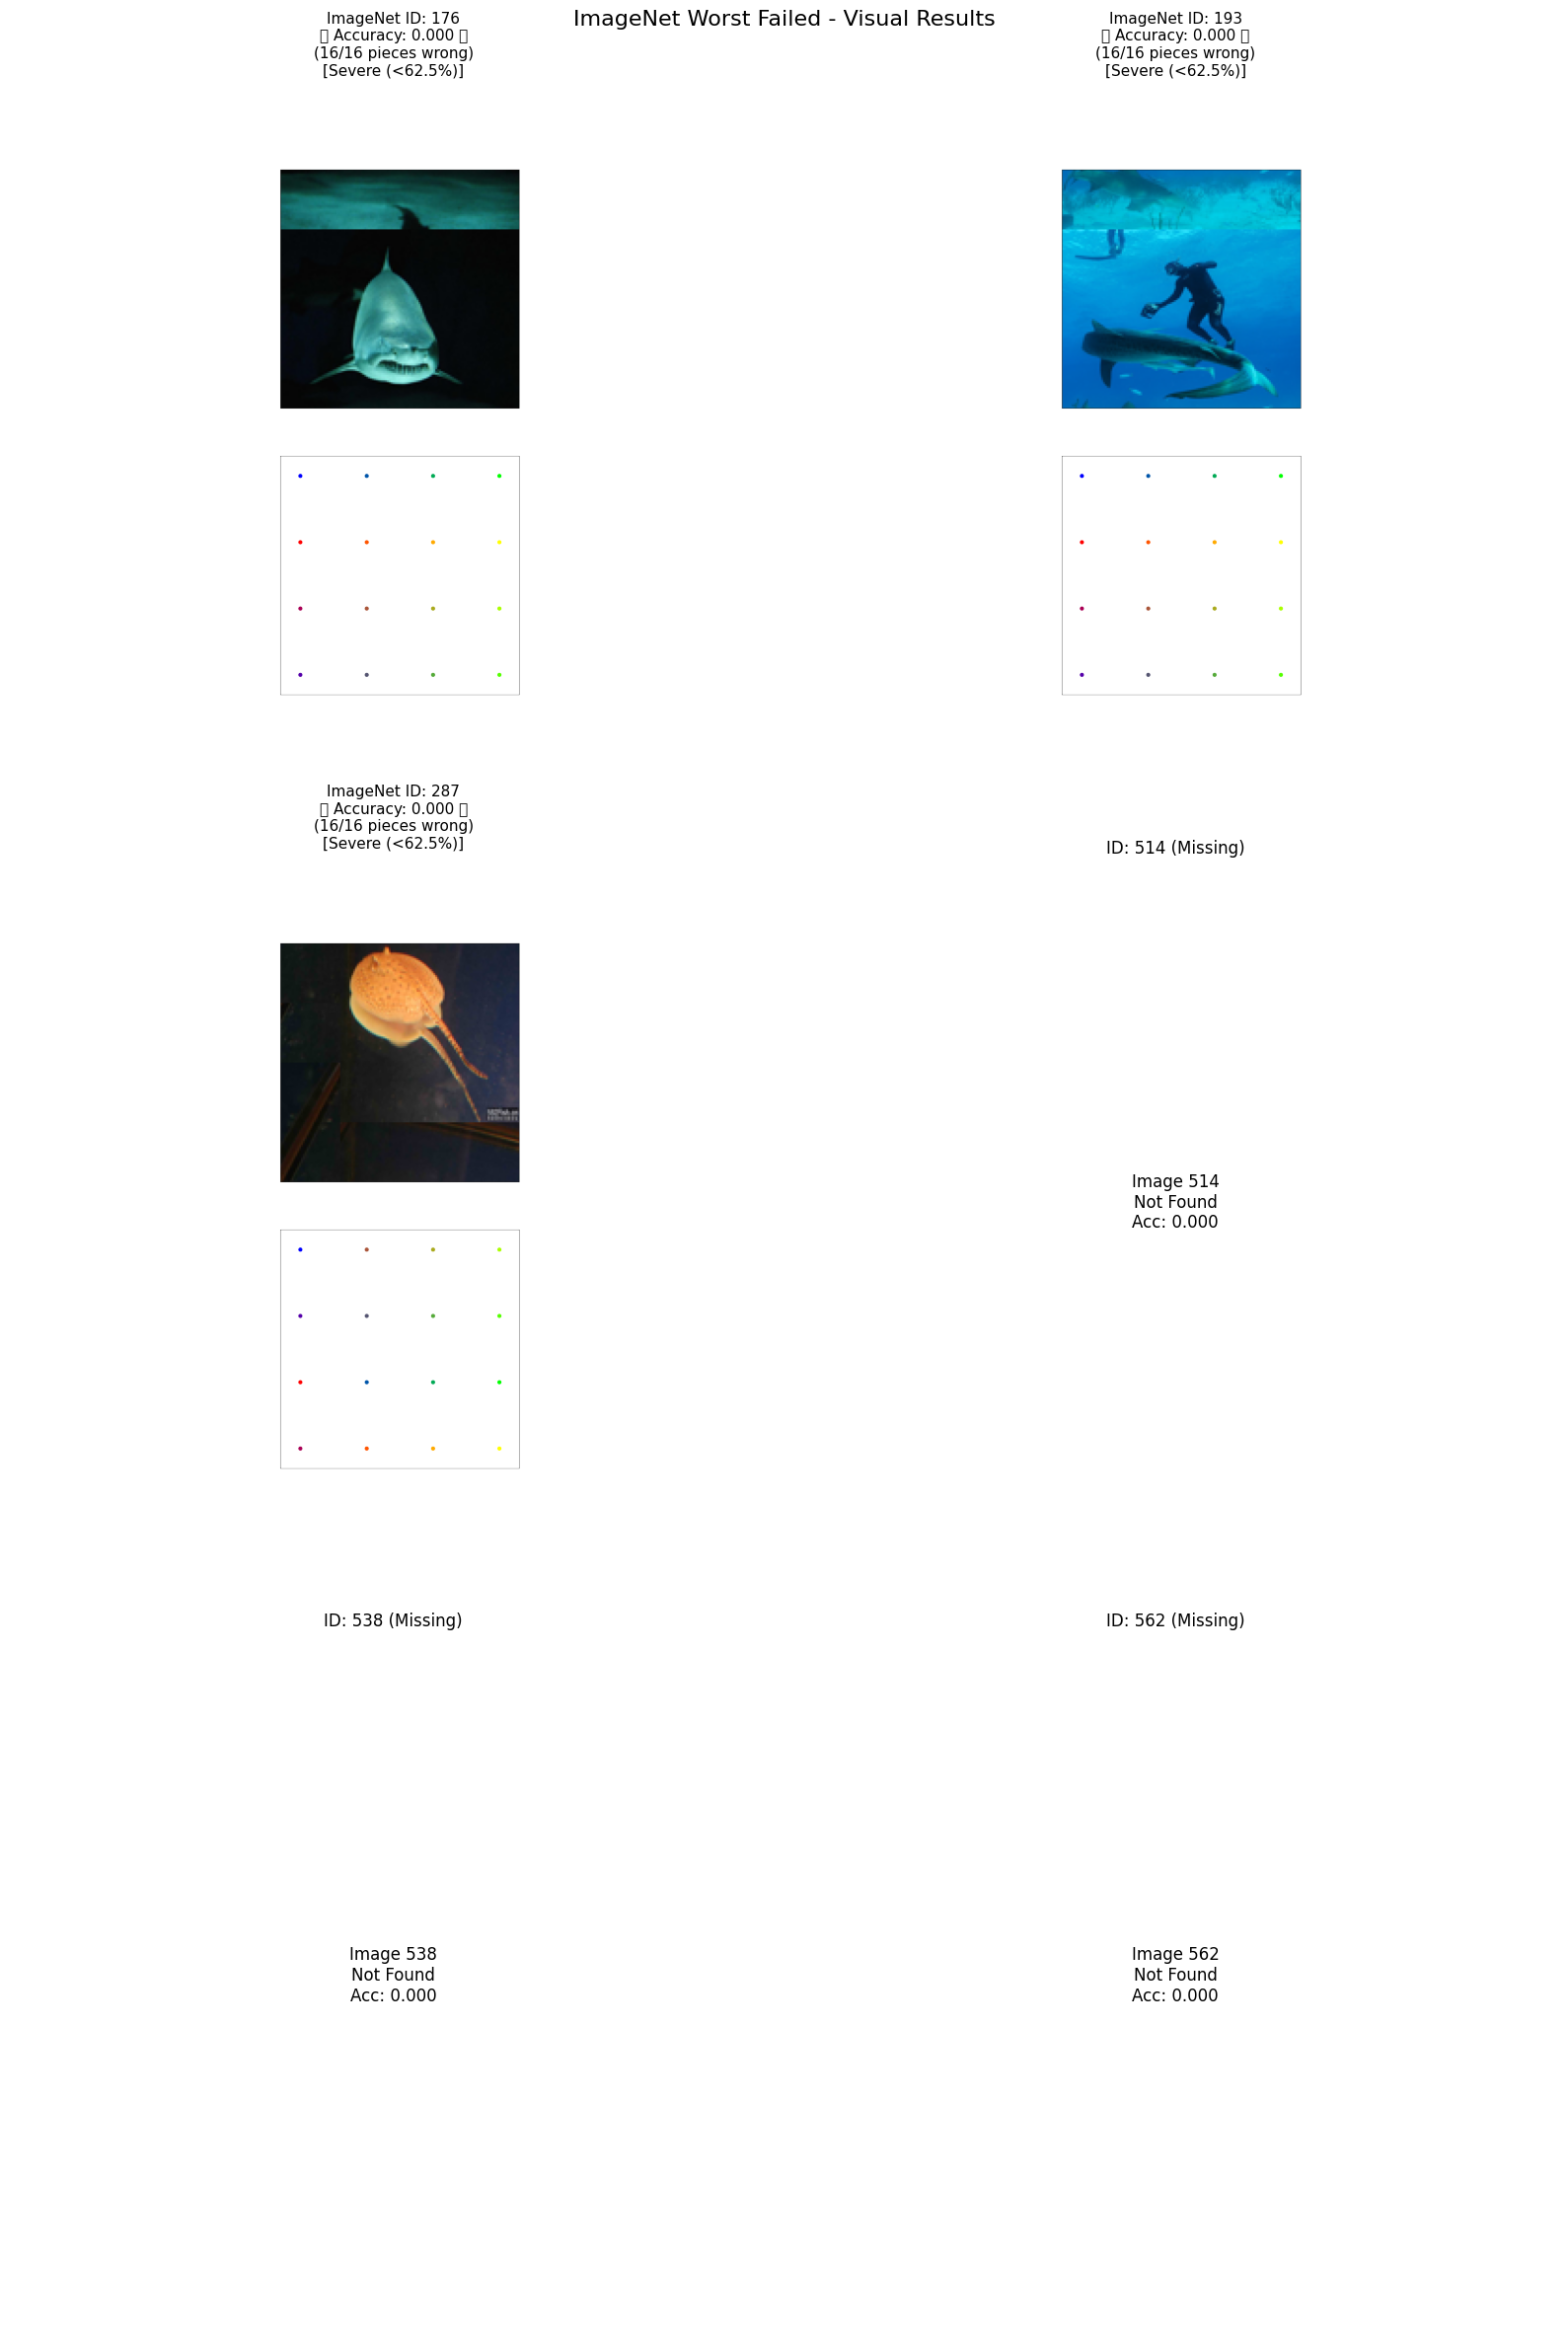


⚠️  SEVERE IMAGENET FAILURES (6+ pieces wrong)


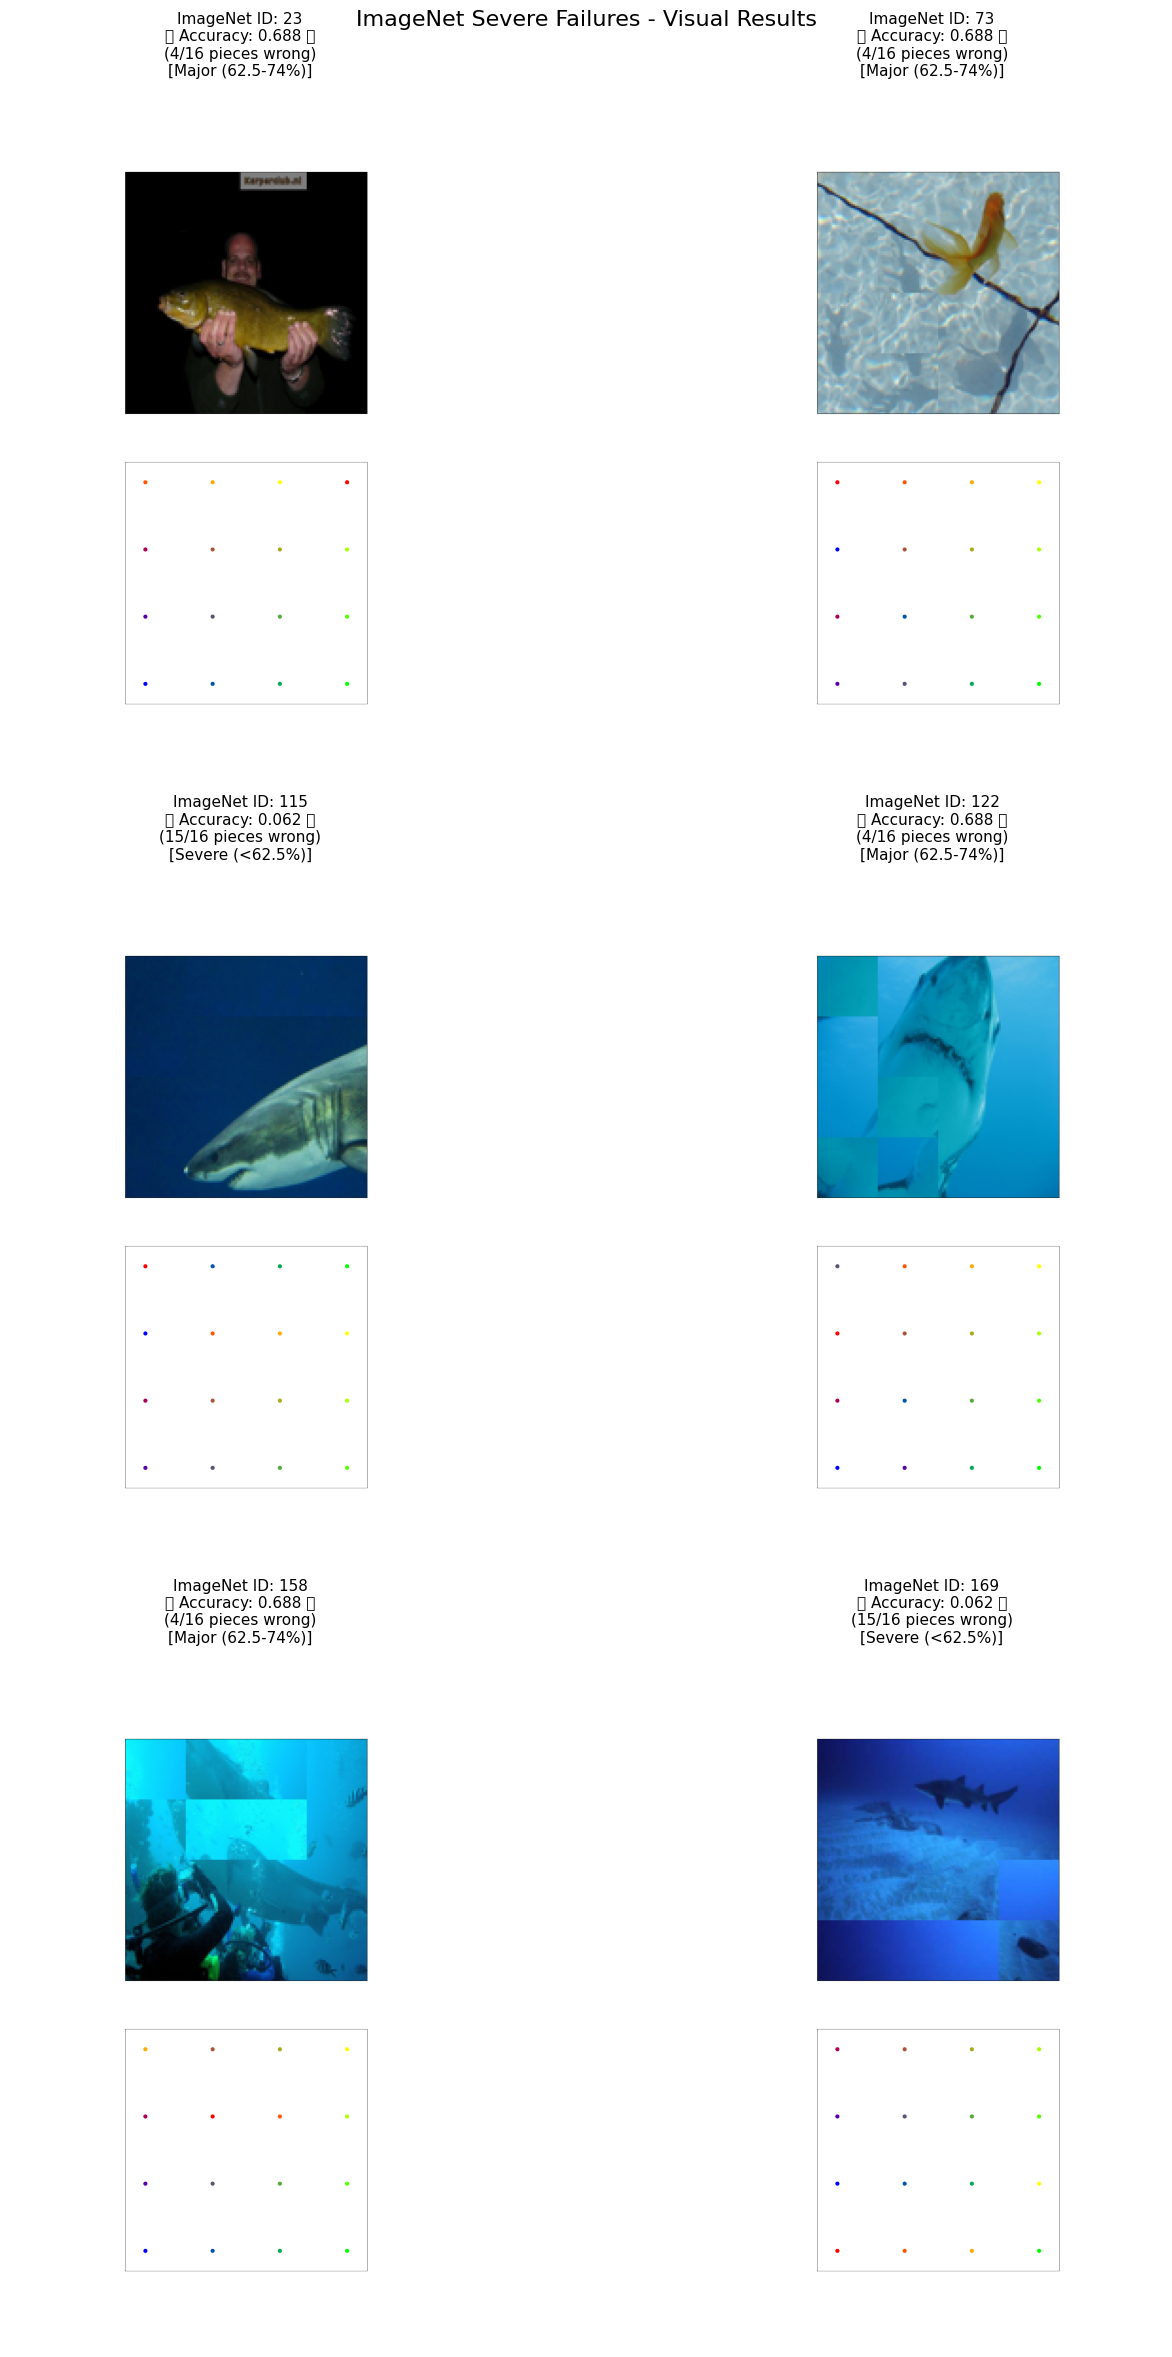


📊 MODERATE IMAGENET FAILURES (2-4 pieces wrong)


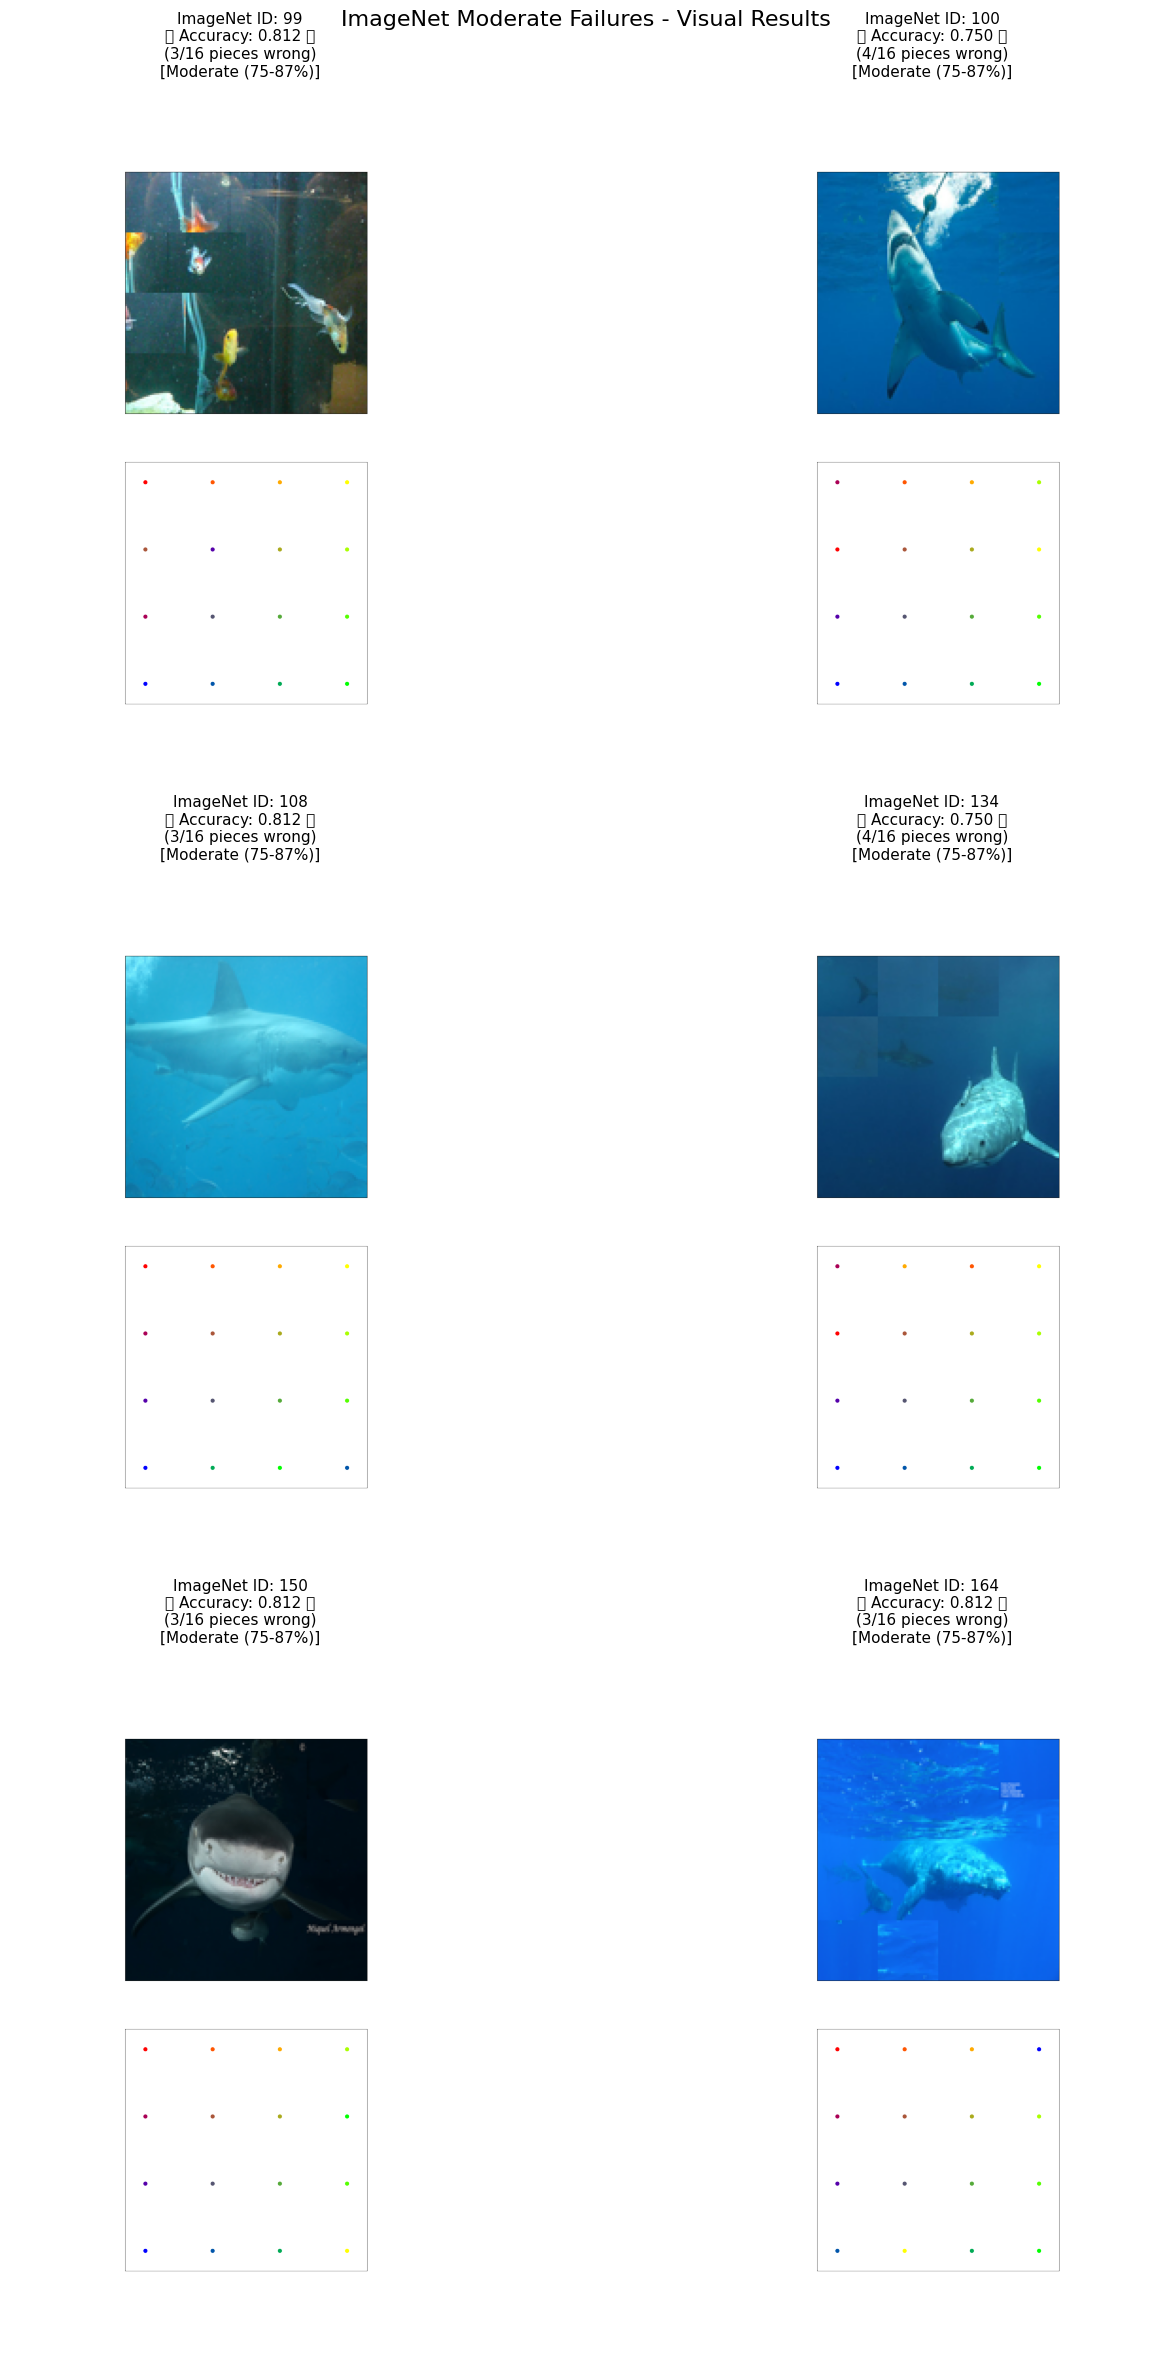


😊 CLOSE CALLS - Best Failed Cases (almost perfect)


/tmp/ipykernel_453182/427742624.py:136: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user1/miniconda3/envs/diffassemble/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


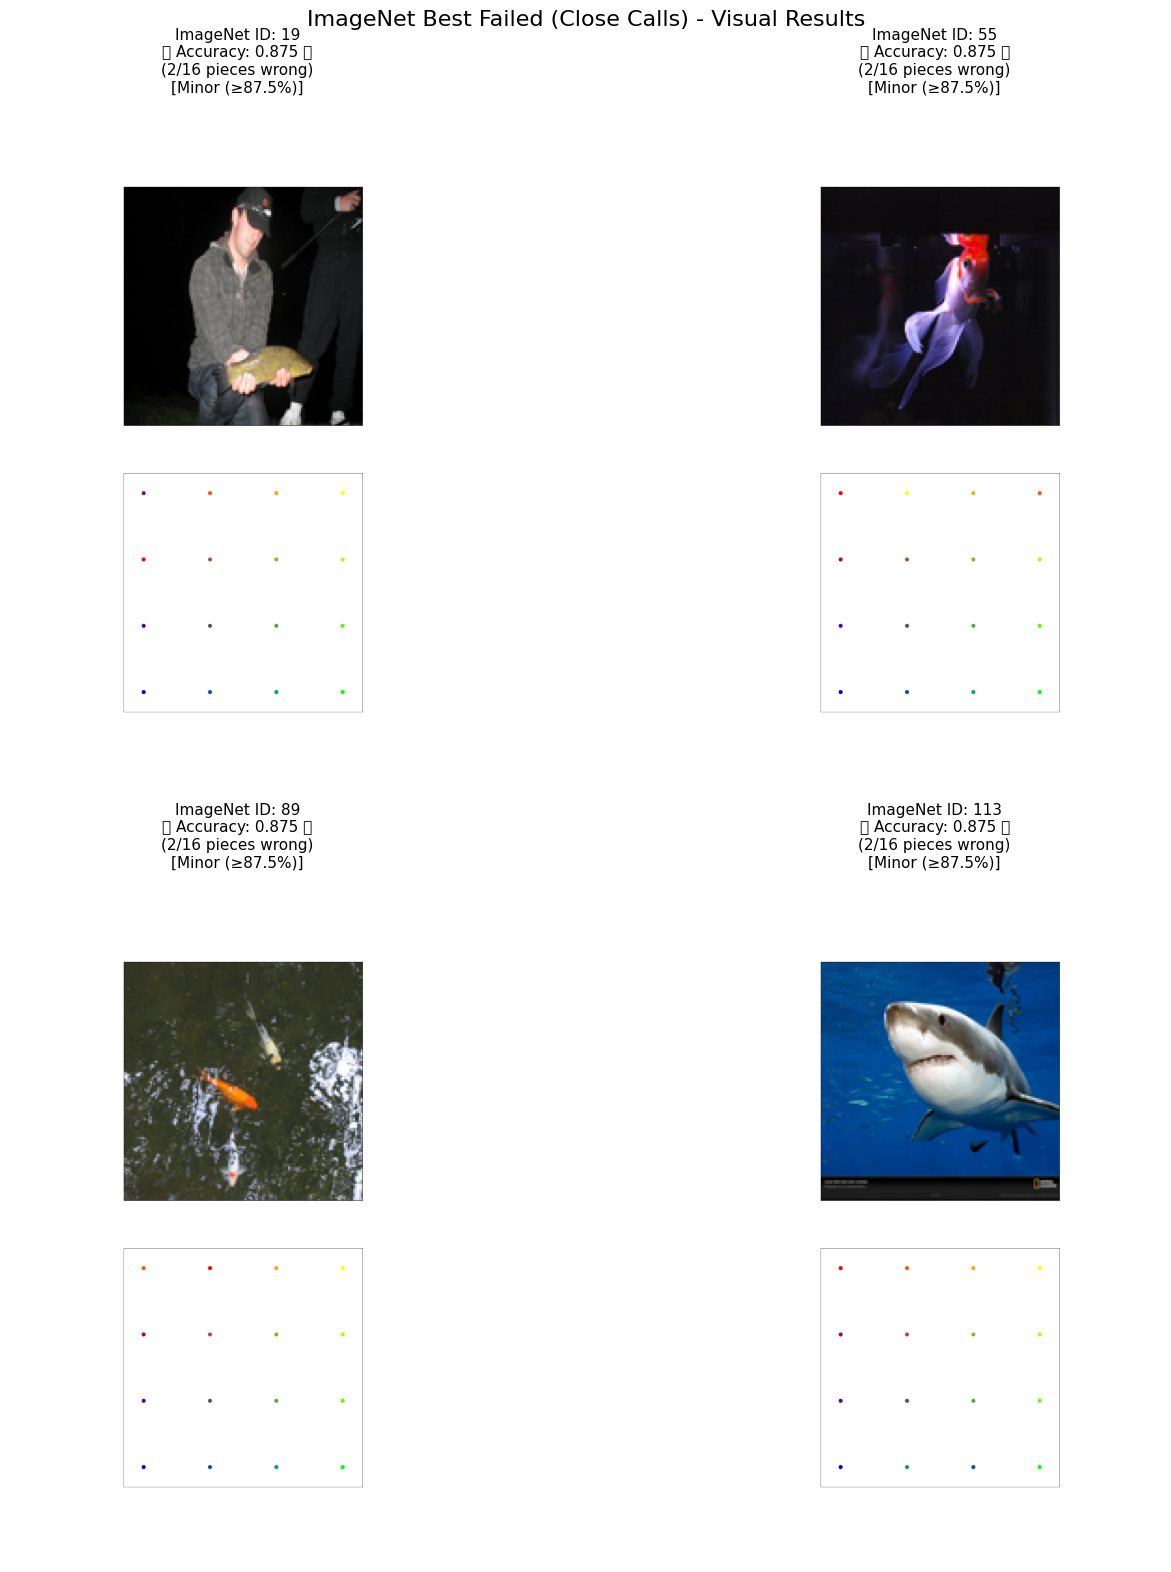


✅ PERFECT IMAGENET SOLUTIONS (100% accuracy)


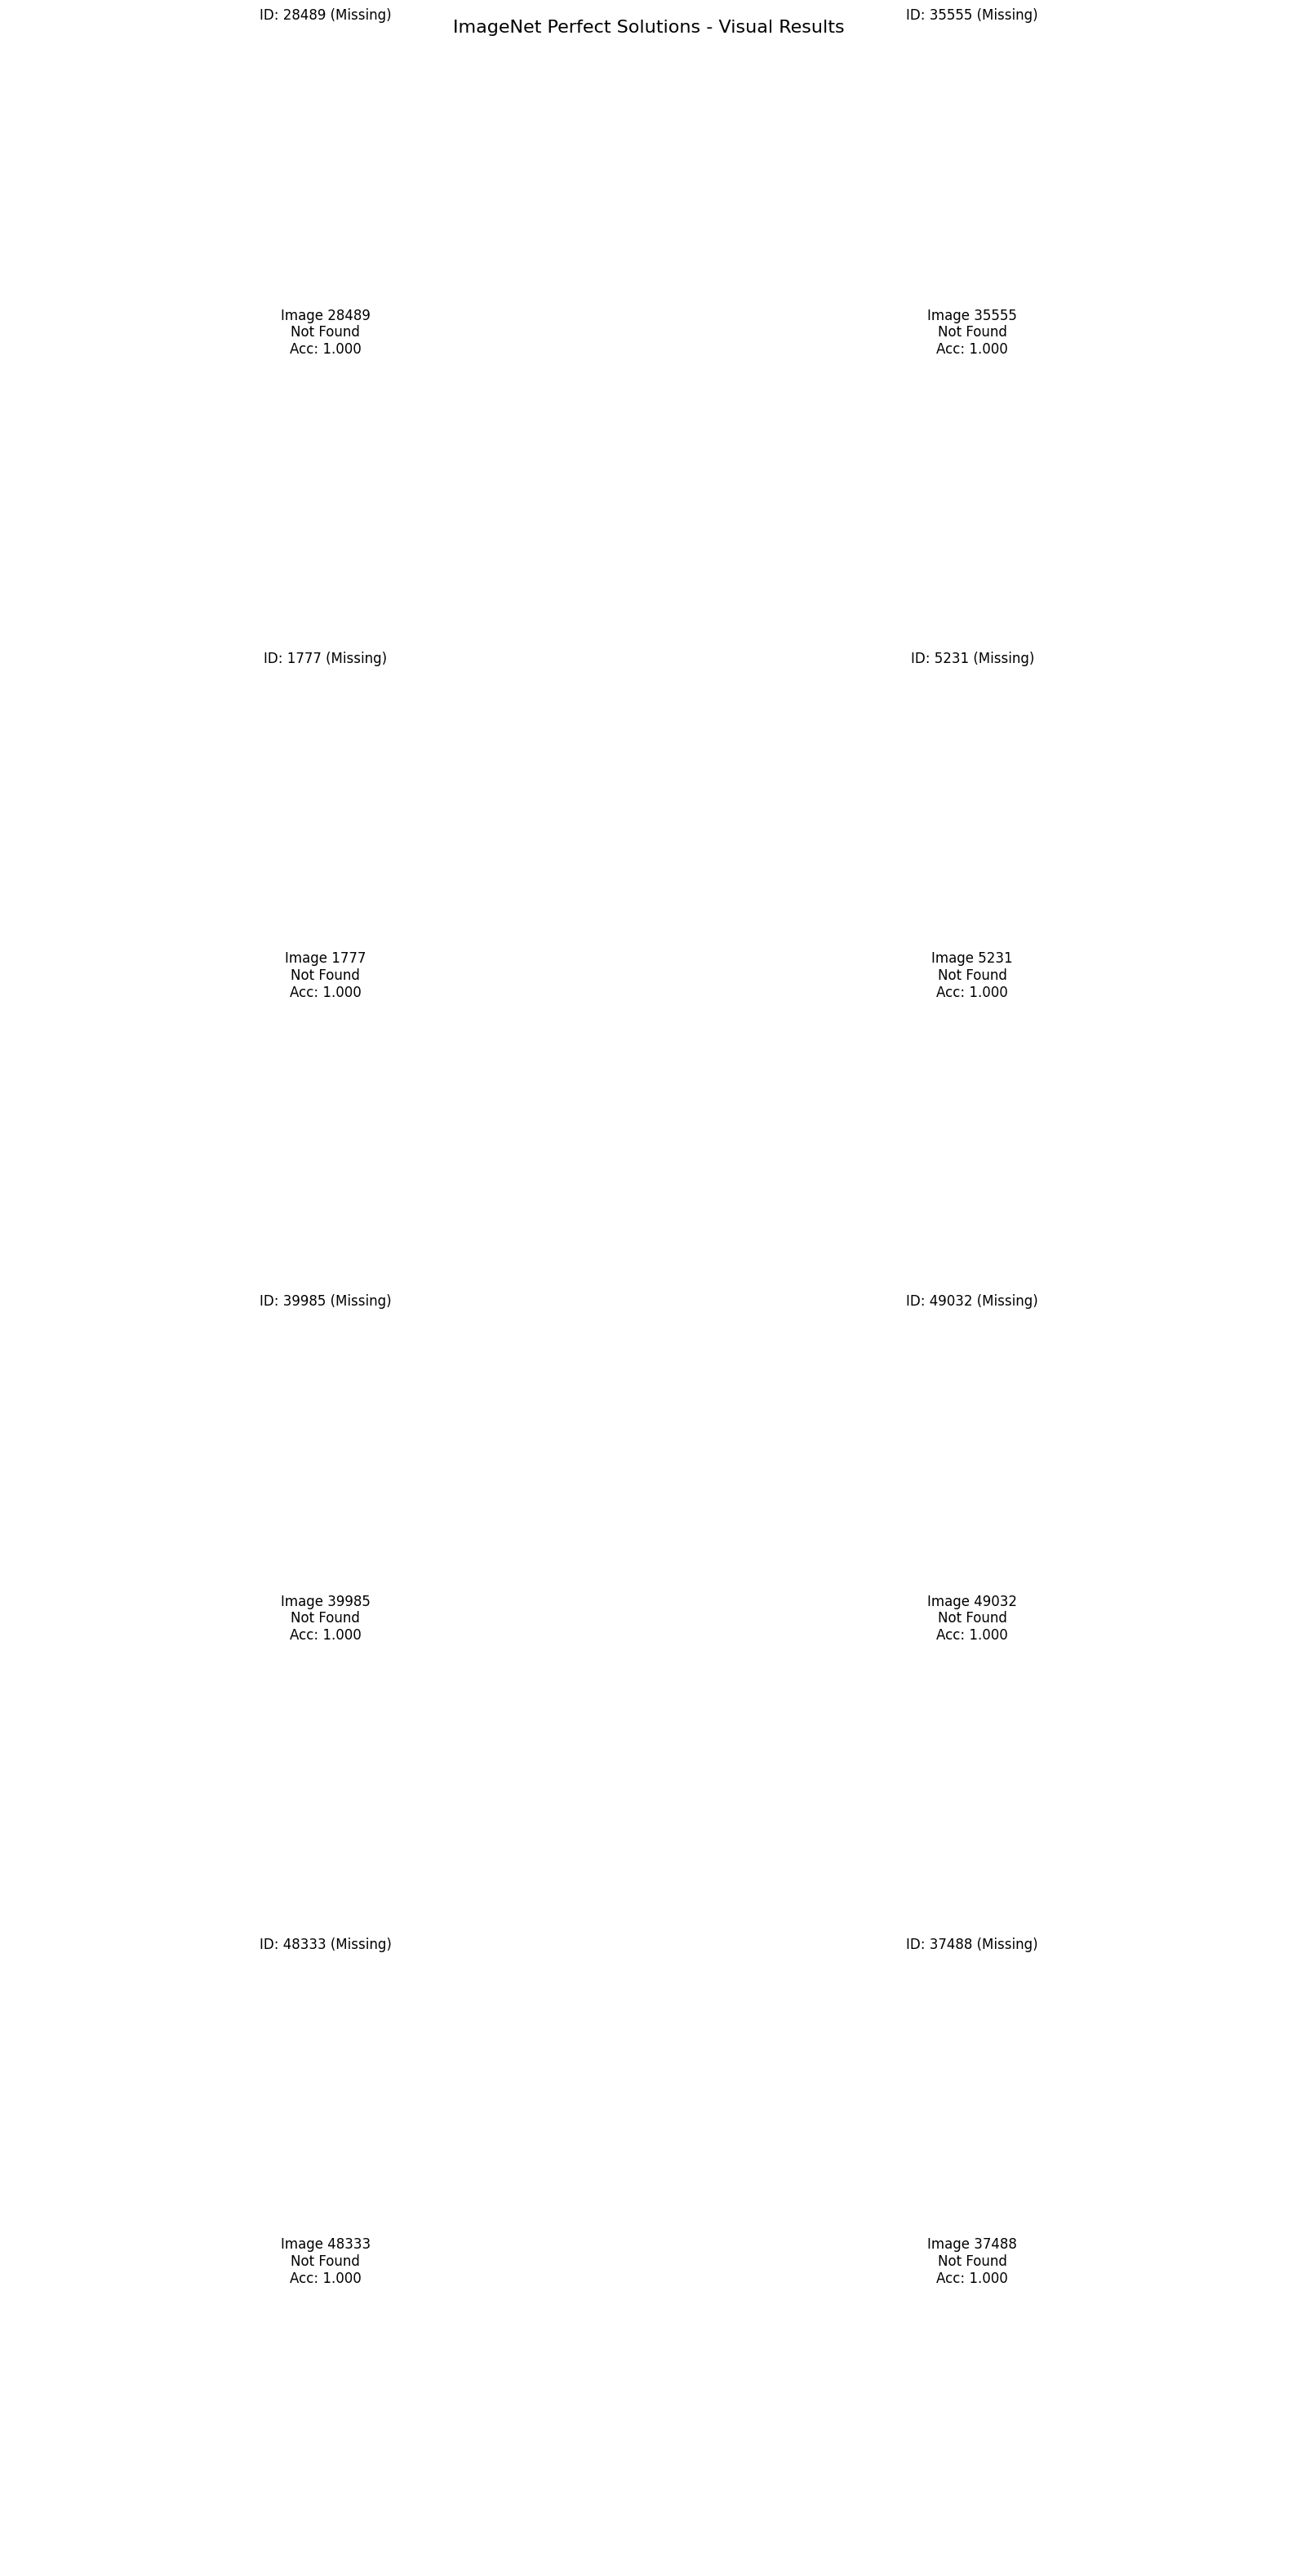


🎲 RANDOM SAMPLE of ImageNet Failures


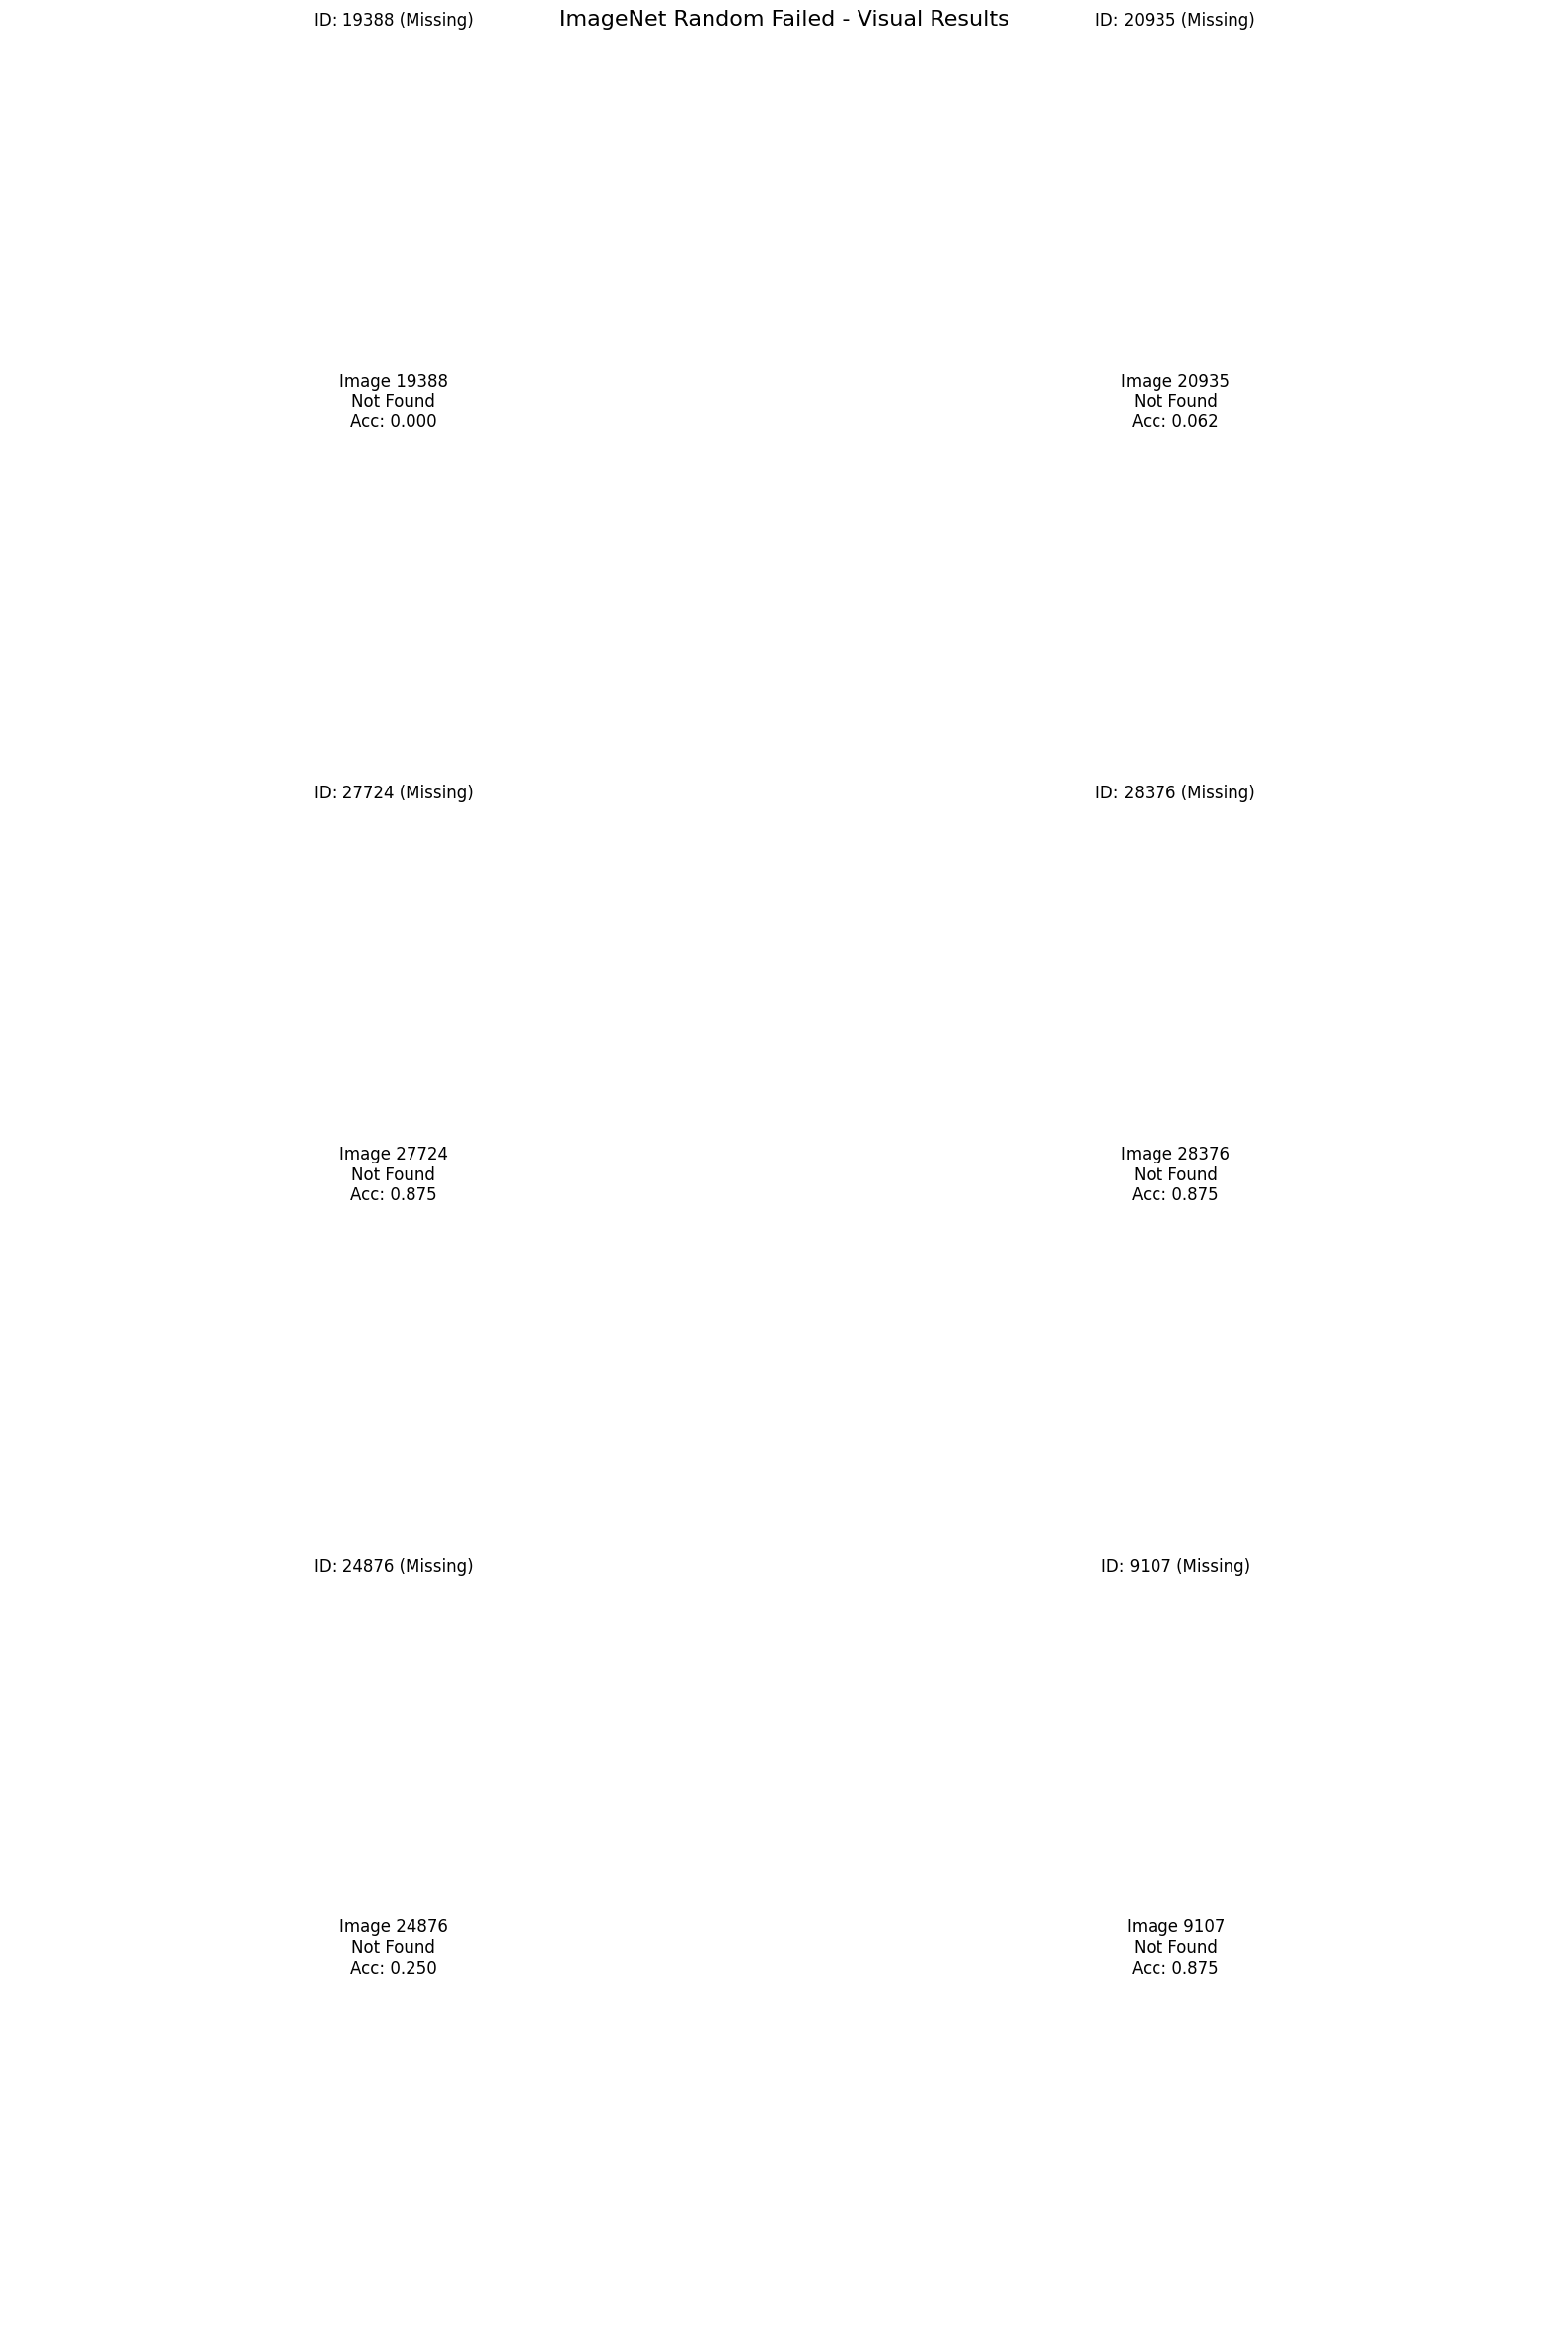


📈 IMAGENET PERFORMANCE SUMMARY
🎯 Total Images Tested: 50,000
✅ Perfect Solutions: 46,171 (92.34%)
❌ Failed Puzzles: 3,829 (7.66%)
🏆 Success Rate: 92.34%

📊 Failure Type Distribution:
   Severe (<62.5%): 1,356 cases (35.4% of failures)
   Minor (≥87.5%): 1,290 cases (33.7% of failures)
   Moderate (75-87%): 863 cases (22.5% of failures)
   Major (62.5-74%): 320 cases (8.4% of failures)

🎉 ImageNet Analysis Complete!


In [6]:
# Complete ImageNet Analysis and Visualization Cell
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

print("=== COMPLETE IMAGENET ANALYSIS ===")

# Load the ImageNet failed puzzles data (make sure this is from ImageNet run!)
imagenet_failed_data = pd.read_csv('failed_puzzles.log', 
                                  names=['image_id', 'piece_accuracy', 'perfect_puzzle'])

print(f"Total ImageNet failed puzzles: {len(imagenet_failed_data)}")
print(f"Total test images: 50000")
print(f"Success rate: {(50000-len(imagenet_failed_data))/50000*100:.2f}%")
print(f"Failure rate: {len(imagenet_failed_data)/50000*100:.2f}%")

# Basic failure statistics
print(f"\nAverage piece accuracy in failed cases: {imagenet_failed_data['piece_accuracy'].mean():.3f}")
print(f"Worst case accuracy: {imagenet_failed_data['piece_accuracy'].min():.3f}")
print(f"Best failed case accuracy: {imagenet_failed_data['piece_accuracy'].max():.3f}")

# Categorize ImageNet failures
def categorize_failure(acc):
    if acc >= 0.875:
        return "Minor (≥87.5%)"  # 1-2 pieces wrong
    elif acc >= 0.75:
        return "Moderate (75-87%)"  # 2-4 pieces wrong  
    elif acc >= 0.625:
        return "Major (62.5-74%)"  # 4-6 pieces wrong
    else:
        return "Severe (<62.5%)"  # 6+ pieces wrong

imagenet_failed_data['failure_type'] = imagenet_failed_data['piece_accuracy'].apply(categorize_failure)

# Print failure breakdown
print("\n=== IMAGENET FAILURE BREAKDOWN ===")
imagenet_failure_counts = imagenet_failed_data['failure_type'].value_counts()
for category, count in imagenet_failure_counts.items():
    print(f"{category}: {count} cases ({count/len(imagenet_failed_data)*100:.1f}%)")

# Correct path to ImageNet results
imagenet_results_path = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/imagenet-[(4, 4)]-300-degree:100%-virtnode:4-prrumw-continuous-ours_dropout-arch-transformer/test/"

# Universal visualization function for ImageNet
def visualize_imagenet_cases(num_cases=8, case_type="worst"):
    """
    Visualize ImageNet puzzle cases - 2 per row for better analysis
    case_type: "worst", "best_failed", "random_failed", "successful", "severe", "moderate"
    """
    
    if case_type == "worst":
        cases_to_show = imagenet_failed_data.nsmallest(num_cases, 'piece_accuracy')
        title_prefix = "Worst Failed"
    elif case_type == "best_failed":
        cases_to_show = imagenet_failed_data.nlargest(num_cases, 'piece_accuracy')
        title_prefix = "Best Failed (Close Calls)"
    elif case_type == "random_failed":
        cases_to_show = imagenet_failed_data.sample(min(num_cases, len(imagenet_failed_data)))
        title_prefix = "Random Failed"
    elif case_type == "severe":
        severe_cases = imagenet_failed_data[imagenet_failed_data['failure_type'].str.contains('Severe|Major')]
        cases_to_show = severe_cases.head(num_cases)
        title_prefix = "Severe Failures"
    elif case_type == "moderate":
        moderate_cases = imagenet_failed_data[imagenet_failed_data['failure_type'].str.contains('Moderate')]
        cases_to_show = moderate_cases.head(num_cases)
        title_prefix = "Moderate Failures"
    elif case_type == "successful":
        # For successful cases, generate random IDs that aren't in failed_data
        all_ids = set(range(50000))
        failed_ids = set(imagenet_failed_data['image_id'].values)
        successful_ids = list(all_ids - failed_ids)
        random_successful = np.random.choice(successful_ids, min(num_cases, len(successful_ids)), replace=False)
        
        # Create dataframe for successful cases
        cases_to_show = pd.DataFrame({
            'image_id': random_successful,
            'piece_accuracy': [1.0] * len(random_successful),  # Perfect accuracy
            'perfect_puzzle': [True] * len(random_successful)
        })
        title_prefix = "Perfect Solutions"
    
    # Create subplot grid - 2 columns for better detail view
    cols = 2
    rows = (num_cases + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8*rows))
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(cases_to_show.iterrows()):
        if idx >= num_cases:
            break
            
        image_id = int(row['image_id'])
        piece_acc = row['piece_accuracy']
        pieces_wrong = int(16 * (1 - piece_acc)) if piece_acc < 1.0 else 0
        
        # ImageNet filename format
        image_name = f"{image_id}_final.png"
        image_path = os.path.join(imagenet_results_path, image_name)
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                axes[idx].imshow(img)
                
                if case_type == "successful":
                    axes[idx].set_title(f'ImageNet ID: {image_id}\n✅ PERFECT SOLUTION ✅\n(All 16 pieces correct)', 
                                      fontsize=12, pad=10, color='green', weight='bold')
                else:
                    failure_type = row.get('failure_type', 'Unknown')
                    axes[idx].set_title(f'ImageNet ID: {image_id}\n❌ Accuracy: {piece_acc:.3f} ❌\n({pieces_wrong}/16 pieces wrong)\n[{failure_type}]', 
                                      fontsize=11, pad=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Image {image_id}\nError loading\nAcc: {piece_acc:.3f}', 
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
                axes[idx].set_title(f'ID: {image_id} (Error)', fontsize=12)
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'Image {image_id}\nNot Found\nAcc: {piece_acc:.3f}', 
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
            axes[idx].set_title(f'ID: {image_id} (Missing)', fontsize=12)
            axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(len(cases_to_show), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'ImageNet {title_prefix} - Visual Results', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# Check if ImageNet results exist and run all visualizations
print("\n=== CHECKING IMAGENET SAVED IMAGES ===")
if os.path.exists(imagenet_results_path):
    files = os.listdir(imagenet_results_path)
    print(f"Total files in ImageNet results: {len(files)}")
    
    final_images = [f for f in files if 'final' in f.lower()]
    print(f"Final puzzle images found: {len(final_images)}")
    
    if len(final_images) > 0:
        print("Example filenames:")
        for i, fname in enumerate(final_images[:5]):
            print(f"  {fname}")
        
        # Run all visualizations
        print("\n" + "="*60)
        print("🔥 WORST IMAGENET FAILURES (Completely Broken)")
        print("="*60)
        visualize_imagenet_cases(num_cases=6, case_type="worst")
        
        print("\n" + "="*60)
        print("⚠️  SEVERE IMAGENET FAILURES (6+ pieces wrong)")
        print("="*60)
        visualize_imagenet_cases(num_cases=6, case_type="severe")
        
        print("\n" + "="*60)
        print("📊 MODERATE IMAGENET FAILURES (2-4 pieces wrong)")
        print("="*60)
        visualize_imagenet_cases(num_cases=6, case_type="moderate")
        
        print("\n" + "="*60)
        print("😊 CLOSE CALLS - Best Failed Cases (almost perfect)")
        print("="*60)
        visualize_imagenet_cases(num_cases=4, case_type="best_failed")
        
        print("\n" + "="*60)
        print("✅ PERFECT IMAGENET SOLUTIONS (100% accuracy)")
        print("="*60)
        visualize_imagenet_cases(num_cases=8, case_type="successful")
        
        print("\n" + "="*60)
        print("🎲 RANDOM SAMPLE of ImageNet Failures")
        print("="*60)
        visualize_imagenet_cases(num_cases=6, case_type="random_failed")
        
        # Summary statistics
        print("\n" + "="*60)
        print("📈 IMAGENET PERFORMANCE SUMMARY")
        print("="*60)
        print(f"🎯 Total Images Tested: 50,000")
        print(f"✅ Perfect Solutions: {50000 - len(imagenet_failed_data):,} ({(50000-len(imagenet_failed_data))/50000*100:.2f}%)")
        print(f"❌ Failed Puzzles: {len(imagenet_failed_data):,} ({len(imagenet_failed_data)/50000*100:.2f}%)")
        print(f"🏆 Success Rate: {(50000-len(imagenet_failed_data))/50000*100:.2f}%")
        
        print("\n📊 Failure Type Distribution:")
        for category, count in imagenet_failure_counts.items():
            percentage = count/len(imagenet_failed_data)*100
            print(f"   {category}: {count:,} cases ({percentage:.1f}% of failures)")
            
    else:
        print("❌ No final images found! Need to run evaluation with --save_eval_images True")
        
else:
    print(f"❌ ImageNet results path not found: {imagenet_results_path}")
    print("\n🔍 Searching for available ImageNet result directories...")
    
    base_results = "/home/user1/Desktop/HAMZA/THESIS/DiffAssemble/results/"
    if os.path.exists(base_results):
        print("\n📁 Available result directories:")
        for d in os.listdir(base_results):
            if 'imagenet' in d.lower():
                print(f"   📂 {d}")
                
        print(f"\n💡 Update imagenet_results_path variable to the correct directory above!")
    else:
        print("❌ Results directory not found!")

print("\n🎉 ImageNet Analysis Complete!")